# BMDS2003 Data Science — Group Project
## Estimation of Obesity Levels Based on Eating Habits and Physical Condition

**CRISP-DM Framework Implementation**

This notebook applies the Cross Industry Standard Process for Data Mining (CRISP-DM) to the
UCI *Estimation of Obesity Levels* dataset. Four classification models are trained to predict a
person's obesity category from lifestyle, eating-habit, and physical-condition attributes:

| Model | Role | Owner |
|---|---|---|
| Decision Tree | Baseline model | Kyra |
| Random Forest | Model 2 | Liping |
| Support Vector Machine (SVM) | Model 3 | Wenhsuan |
| K-Nearest Neighbours (KNN) | Model 4 | Gladys |

> Short interpretation notes are included after each analysis/plot for quick reference in class.
> Fuller discussion belongs in the written report (Business Understanding, Evaluation, Conclusion
> sections).

## 1. Import Libraries

In [1]:
# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import json
import joblib
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

RANDOM_STATE = 42
N_FOLDS = 5  # number of cross-validation folds used consistently across all 4 models

print("Libraries imported successfully.")
print("Random seed fixed at:", RANDOM_STATE)
print("Cross-validation folds (N):", N_FOLDS)

Libraries imported successfully.
Random seed fixed at: 42
Cross-validation folds (N): 5


## 2. Data Understanding

In [2]:
# ============================================================
# 2. DATA UNDERSTANDING
# ============================================================

# Load the original dataset
obesity = pd.read_csv("obesity.csv")

# ------------------------------------------------------------
# 2.1 Preview the dataset
# ------------------------------------------------------------

print("First five rows:")
display(obesity.head())

print("\nLast five rows:")
display(obesity.tail())

# ------------------------------------------------------------
# 2.2 Check dataset dimensions
# ------------------------------------------------------------

print("Number of rows:", obesity.shape[0])
print("Number of columns:", obesity.shape[1])

# ------------------------------------------------------------
# 2.3 Examine dataset structure
# ------------------------------------------------------------

print("\nDataset information:")
obesity.info()

# ------------------------------------------------------------
# 2.4 Display column names
# ------------------------------------------------------------

print("\nColumn names:")
print(obesity.columns.tolist())

# ------------------------------------------------------------
# 2.5 Identify numerical and categorical columns
# ------------------------------------------------------------

numerical_cols = obesity.select_dtypes(include=np.number).columns.tolist()
categorical_cols = obesity.select_dtypes(exclude=np.number).columns.tolist()

print("\nNumerical columns:")
print(numerical_cols)

print("\nCategorical columns:")
print(categorical_cols)

# ------------------------------------------------------------
# 2.6 Summary statistics for numerical variables
# ------------------------------------------------------------

print("\nNumerical summary statistics:")
display(obesity[numerical_cols].describe().T)

# ------------------------------------------------------------
# 2.7 Summary statistics for categorical variables
# ------------------------------------------------------------

print("\nCategorical summary statistics:")
display(obesity[categorical_cols].describe().T)

# ------------------------------------------------------------
# 2.8 Count unique values in every column
# ------------------------------------------------------------

unique_counts = obesity.nunique().sort_values()

print("\nNumber of unique values in each column:")
display(unique_counts.to_frame(name="Unique_Values"))

# ------------------------------------------------------------
# 2.9 Display categories in each categorical column
# ------------------------------------------------------------

print("\nUnique categories in categorical variables:")

for col in categorical_cols:
    print(f"\n{col}:")
    print(obesity[col].unique())

# ------------------------------------------------------------
# 2.10 Examine target-variable distribution
# ------------------------------------------------------------

target_counts = obesity["NObeyesdad"].value_counts()

target_percentages = (
    obesity["NObeyesdad"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

target_summary = pd.DataFrame({
    "Count": target_counts,
    "Percentage": target_percentages
})

print("\nObesity-level distribution:")
display(target_summary)

First five rows:


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II



Last five rows:


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
2106,Female,20.976842,1.710730,131.408528,yes,yes,3.0,3.0,Sometimes,no,1.728139,no,1.676269,0.906247,Sometimes,Public_Transportation,Obesity_Type_III
2107,Female,21.982942,1.748584,133.742943,yes,yes,3.0,3.0,Sometimes,no,2.005130,no,1.341390,0.599270,Sometimes,Public_Transportation,Obesity_Type_III
2108,Female,22.524036,1.752206,133.689352,yes,yes,3.0,3.0,Sometimes,no,2.054193,no,1.414209,0.646288,Sometimes,Public_Transportation,Obesity_Type_III
2109,Female,24.361936,1.739450,133.346641,yes,yes,3.0,3.0,Sometimes,no,2.852339,no,1.139107,0.586035,Sometimes,Public_Transportation,Obesity_Type_III
2110,Female,23.664709,1.738836,133.472641,yes,yes,3.0,3.0,Sometimes,no,2.863513,no,1.026452,0.714137,Sometimes,Public_Transportation,Obesity_Type_III


Number of rows: 2111
Number of columns: 17

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   str    
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   str    
 5   FAVC                            2111 non-null   str    
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   str    
 9   SMOKE                           2111 non-null   str    
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-

...

,count,unique,top,freq
Gender,2111,2,Male,1068
family_history_with_overweight,2111,2,yes,1726
FAVC,2111,2,yes,1866
CAEC,2111,4,Sometimes,1765
SMOKE,2111,2,no,2067
SCC,2111,2,no,2015
CALC,2111,4,Sometimes,1401
MTRANS,2111,5,Public_Transportation,1580
NObeyesdad,2111,7,Obesity_Type_I,351



Number of unique values in each column:


,Unique_Values
Gender,2
family_history_with_overweight,2
FAVC,2
SMOKE,2
SCC,2
CAEC,4
CALC,4
MTRANS,5
NObeyesdad,7
NCP,635



Unique categories in categorical variables:

Gender:
<StringArray>
['Female', 'Male']
Length: 2, dtype: str

family_history_with_overweight:
<StringArray>
['yes', 'no']
Length: 2, dtype: str

FAVC:
<StringArray>
['no', 'yes']
Length: 2, dtype: str

CAEC:
<StringArray>
['Sometimes', 'Frequently', 'Always', 'no']
Length: 4, dtype: str

SMOKE:
<StringArray>
['no', 'yes']
Length: 2, dtype: str

SCC:
<StringArray>
['no', 'yes']
Length: 2, dtype: str

CALC:
<StringArray>
['no', 'Sometimes', 'Frequently', 'Always']
Length: 4, dtype: str

MTRANS:
<StringArray>
['Public_Transportation', 'Walking', 'Automobile', 'Motorbike', 'Bike']
Length: 5, dtype: str

NObeyesdad:
<StringArray>
[      'Normal_Weight',  'Overweight_Level_I', 'Overweight_Level_II',
      'Obesity_Type_I', 'Insufficient_Weight',     'Obesity_Type_II',
    'Obesity_Type_III']
Length: 7, dtype: str

Obesity-level distribution:


,Count,Percentage
NObeyesdad,,
Obesity_Type_I,351,16.63
Obesity_Type_III,324,15.35
Obesity_Type_II,297,14.07
Overweight_Level_I,290,13.74
Overweight_Level_II,290,13.74
Normal_Weight,287,13.60
Insufficient_Weight,272,12.88


**Short interpretation:** The dataset has 2,111 records and 17 columns (16 predictors + 1
target, `NObeyesdad`). There are 8 numeric columns and 9 categorical/text columns, no missing
values are visible at a glance (confirmed formally in Data Preparation), and the target has
**7 classes** that are reasonably — but not perfectly — balanced (`Obesity_Type_I` is the largest
class, `Insufficient_Weight` and `Obesity_Type_II`/`III` are somewhat smaller). This means
**stratified sampling** and **weighted evaluation metrics** will be needed later.

## 3. Data Preparation

In [3]:
# ============================================================
# 3. DATA PREPARATION
# ============================================================

# Create a copy so that the original dataset remains unchanged
obesity_cleaned = obesity.copy()

# ------------------------------------------------------------
# 3.1 Check missing values
# ------------------------------------------------------------

missing_summary = pd.DataFrame({
   "Missing_Count": obesity_cleaned.isnull().sum(),
   "Missing_Percentage": (
       obesity_cleaned.isnull().mean() * 100
   ).round(2)
})

print("Missing-value summary:")
display(missing_summary)

print(
   "Total missing values:",
   obesity_cleaned.isnull().sum().sum()
)

Missing-value summary:


,Missing_Count,Missing_Percentage
Gender,0,0.0
Age,0,0.0
Height,0,0.0
Weight,0,0.0
family_history_with_overweight,0,0.0
FAVC,0,0.0
FCVC,0,0.0
NCP,0,0.0
CAEC,0,0.0
SMOKE,0,0.0


Total missing values: 0


In [4]:
# ------------------------------------------------------------
# 3.2 Rename columns ("rename factors") for readability
# ------------------------------------------------------------
# The raw dataset uses short/abbreviated survey codes (e.g. FCVC, NCP, CH2O).
# We rename them to descriptive, self-explanatory names so that every table,
# plot legend, and model report is readable without a data dictionary.

rename_map = {
    "NObeyesdad": "Obesity_Level",
    "family_history_with_overweight": "Family_History_Overweight",
    "FAVC": "Frequent_High_Caloric_Food",
    "FCVC": "Vegetable_Consumption_Freq",
    "NCP": "Main_Meals_Per_Day",
    "CAEC": "Food_Between_Meals",
    "SMOKE": "Smokes",
    "CH2O": "Daily_Water_Intake",
    "SCC": "Calorie_Monitoring",
    "FAF": "Physical_Activity_Freq",
    "TUE": "Technology_Usage_Time",
    "CALC": "Alcohol_Consumption",
    "MTRANS": "Transportation_Mode",
}

obesity_cleaned.rename(columns=rename_map, inplace=True)

print("Updated column names:")
print(obesity_cleaned.columns.tolist())

Updated column names:
['Gender', 'Age', 'Height', 'Weight', 'Family_History_Overweight', 'Frequent_High_Caloric_Food', 'Vegetable_Consumption_Freq', 'Main_Meals_Per_Day', 'Food_Between_Meals', 'Smokes', 'Daily_Water_Intake', 'Calorie_Monitoring', 'Physical_Activity_Freq', 'Technology_Usage_Time', 'Alcohol_Consumption', 'Transportation_Mode', 'Obesity_Level']


In [5]:
# ------------------------------------------------------------
# 3.3 Check and remove duplicate records
# ------------------------------------------------------------

duplicate_count = obesity_cleaned.duplicated().sum()

print("Duplicate records before removal:", duplicate_count)
print("Shape before duplicate removal:", obesity_cleaned.shape)

obesity_cleaned.drop_duplicates(inplace=True)

# Reset the index after removing duplicate rows
obesity_cleaned.reset_index(drop=True, inplace=True)

print("Shape after duplicate removal:", obesity_cleaned.shape)
print(
   "Remaining duplicate records:",
   obesity_cleaned.duplicated().sum()
)

Duplicate records before removal: 24
Shape before duplicate removal: (2111, 17)
Shape after duplicate removal: (2087, 17)
Remaining duplicate records: 0


In [6]:
# ------------------------------------------------------------
# 3.4 Standardise categorical text formats
# ------------------------------------------------------------

categorical_cols_cleaned = obesity_cleaned.select_dtypes(exclude=np.number).columns

# Remove accidental leading/trailing spaces from text values
for col in categorical_cols_cleaned:
    obesity_cleaned[col] = obesity_cleaned[col].astype(str).str.strip()

print("Categorical text values were checked and trimmed.")

pd.set_option("display.float_format", "{:.2f}".format)

Categorical text values were checked and trimmed.


In [7]:
# ------------------------------------------------------------
# 3.5 Check for impossible or invalid numerical values
# ------------------------------------------------------------

numeric_range_summary = pd.DataFrame({
   "Minimum": obesity_cleaned.select_dtypes(include=np.number).min(),
   "Maximum": obesity_cleaned.select_dtypes(include=np.number).max()
})

print("Numerical value ranges:")
display(numeric_range_summary)

# Logical validity checks
invalid_height = obesity_cleaned[obesity_cleaned["Height"] <= 0]
invalid_weight = obesity_cleaned[obesity_cleaned["Weight"] <= 0]
invalid_age = obesity_cleaned[obesity_cleaned["Age"] <= 0]

print("Invalid Age values:", len(invalid_age))
print("Invalid Height values:", len(invalid_height))
print("Invalid Weight values:", len(invalid_weight))

Numerical value ranges:


,Minimum,Maximum
Age,14.00,61.00
Height,1.45,1.98
Weight,39.00,173.00
Vegetable_Consumption_Freq,1.00,3.00
Main_Meals_Per_Day,1.00,4.00
Daily_Water_Intake,1.00,3.00
Physical_Activity_Freq,0.00,3.00
Technology_Usage_Time,0.00,2.00


Invalid Age values: 0
Invalid Height values: 0
Invalid Weight values: 0


In [8]:
# ------------------------------------------------------------
# 3.6 Outlier detection — IQR method
# ------------------------------------------------------------

continuous_outlier_columns = ["Age", "Height", "Weight"]

def detect_outliers_iqr(df, columns):
    summary = []
    flags = pd.DataFrame(index=df.index)
    for col in columns:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        mask = (df[col] < lower) | (df[col] > upper)
        flags[col] = mask
        summary.append({
            "Variable": col, "Lower_Bound": round(lower, 2), "Upper_Bound": round(upper, 2),
            "Outlier_Count": int(mask.sum()), "Outlier_Percentage": round(mask.mean() * 100, 2)
        })
    return pd.DataFrame(summary), flags

iqr_summary, iqr_flags = detect_outliers_iqr(obesity_cleaned, continuous_outlier_columns)
print("IQR outlier summary:")
display(iqr_summary)

IQR outlier summary:


,Variable,Lower_Bound,Upper_Bound,Outlier_Count,Outlier_Percentage
0,Age,10.79,35.13,167,8.00
1,Height,1.42,1.98,1,0.05
2,Weight,2.98,171.04,1,0.05


In [9]:
# ------------------------------------------------------------
# 3.7 Outlier detection — Z-score method
# ------------------------------------------------------------
# Flags values more than 3 standard deviations from the mean.

def detect_outliers_zscore(df, columns, threshold=3):
    summary = []
    flags = pd.DataFrame(index=df.index)
    for col in columns:
        mean = df[col].mean()
        std = df[col].std()
        z_scores = (df[col] - mean) / std
        mask = z_scores.abs() > threshold
        flags[col] = mask
        summary.append({
            "Variable": col, "Mean": round(mean, 2), "Std_Dev": round(std, 2),
            "Threshold": threshold, "Outlier_Count": int(mask.sum()),
            "Outlier_Percentage": round(mask.mean() * 100, 2)
        })
    return pd.DataFrame(summary), flags

zscore_summary, zscore_flags = detect_outliers_zscore(obesity_cleaned, continuous_outlier_columns)
print("Z-score outlier summary (|z| > 3):")
display(zscore_summary)

Z-score outlier summary (|z| > 3):


,Variable,Mean,Std_Dev,Threshold,Outlier_Count,Outlier_Percentage
0,Age,24.35,6.37,3,23,1.10
1,Height,1.70,0.09,3,0,0.00
2,Weight,86.86,26.19,3,1,0.05


In [10]:
# ------------------------------------------------------------
# 3.8 Outlier detection — Modified Z-score method
# ------------------------------------------------------------
# Uses the median and Median Absolute Deviation (MAD), which is more robust
# to skewed distributions than the mean/std used by the standard Z-score.

def detect_outliers_modified_zscore(df, columns, threshold=3.5):
    summary = []
    flags = pd.DataFrame(index=df.index)
    for col in columns:
        median = df[col].median()
        mad = (df[col] - median).abs().median()
        # 0.6745 scales the MAD to be comparable with the standard deviation
        modified_z = 0.6745 * (df[col] - median) / (mad if mad != 0 else 1e-9)
        mask = modified_z.abs() > threshold
        flags[col] = mask
        summary.append({
            "Variable": col, "Median": round(median, 2), "MAD": round(mad, 2),
            "Threshold": threshold, "Outlier_Count": int(mask.sum()),
            "Outlier_Percentage": round(mask.mean() * 100, 2)
        })
    return pd.DataFrame(summary), flags

modz_summary, modz_flags = detect_outliers_modified_zscore(obesity_cleaned, continuous_outlier_columns)
print("Modified Z-score outlier summary (|M| > 3.5):")
display(modz_summary)

# ------------------------------------------------------------
# Combined comparison of the three outlier-detection methods
# ------------------------------------------------------------

outlier_method_comparison = pd.DataFrame({
    "IQR_Outliers": iqr_summary.set_index("Variable")["Outlier_Count"],
    "Zscore_Outliers": zscore_summary.set_index("Variable")["Outlier_Count"],
    "ModifiedZ_Outliers": modz_summary.set_index("Variable")["Outlier_Count"],
})
print("\nComparison of outlier counts across methods:")
display(outlier_method_comparison)

Modified Z-score outlier summary (|M| > 3.5):


,Variable,Median,MAD,Threshold,Outlier_Count,Outlier_Percentage
0,Age,22.85,3.15,3.50,75,3.59
1,Height,1.70,0.07,3.50,0,0.00
2,Weight,83.10,21.67,3.50,0,0.00



Comparison of outlier counts across methods:


,IQR_Outliers,Zscore_Outliers,ModifiedZ_Outliers
Variable,,,
Age,167,23,75
Height,1,0,0
Weight,1,1,0


**Short interpretation:** All three methods (IQR, Z-score, Modified Z-score) agree that only
a small number of `Age` records are flagged as outliers (a few respondents in their 40s–60s in a
mostly young-adult sample); `Height` and `Weight` show almost no outliers. Because these values are
physiologically plausible (a 50-year-old or a 170 kg adult are real possibilities, not data-entry
errors), **we retain all records** rather than deleting them — removing them would shrink the
already smaller obesity classes (`Obesity_Type_II`/`III`) and bias the model. This decision is
documented here and repeated in the report's Data Preparation section.

In [11]:
# ------------------------------------------------------------
# 3.9 Feature engineering — Body Mass Index (BMI)
# ------------------------------------------------------------
# BMI = Weight (kg) / Height (m)^2 is the clinical standard used to define
# obesity categories, and is a useful variable for EXPLORATORY analysis and
# for sanity-checking the target labels. It is intentionally EXCLUDED from
# the machine-learning feature set in Section 6 because it is a deterministic
# function of Height and Weight (which are already features) — including it
# would let the model trivially "look up" the answer instead of learning
# genuine lifestyle patterns.

obesity_cleaned["BMI"] = (
    obesity_cleaned["Weight"] / (obesity_cleaned["Height"] ** 2)
).round(2)

# ------------------------------------------------------------
# 3.10 Categorisation — Equal-width and Equal-frequency binning of Age
# ------------------------------------------------------------
# Demonstrates two standard categorisation/discretisation techniques.

obesity_cleaned["Age_Group_EqualWidth"] = pd.cut(
    obesity_cleaned["Age"], bins=4,
    labels=["Youngest", "Young_Adult", "Adult", "Older_Adult"]
)

obesity_cleaned["Age_Group_EqualFreq"] = pd.qcut(
    obesity_cleaned["Age"], q=4,
    labels=["Q1_Youngest", "Q2", "Q3", "Q4_Oldest"]
)

print("Equal-width Age bins (roughly equal RANGE per bin):")
display(obesity_cleaned["Age_Group_EqualWidth"].value_counts().sort_index())

print("\nEqual-frequency Age bins (roughly equal COUNT per bin):")
display(obesity_cleaned["Age_Group_EqualFreq"].value_counts().sort_index())

# Age_Group_EqualWidth is used later in EDA (Section 5); both engineered
# columns (BMI, Age_Group_*) are excluded from ML training features in
# Section 6 to avoid leakage / redundancy.
obesity_cleaned.rename(columns={"Age_Group_EqualWidth": "Age_Group"}, inplace=True)
obesity_cleaned.drop(columns=["Age_Group_EqualFreq"], inplace=True)

Equal-width Age bins (roughly equal RANGE per bin):


Age_Group_EqualWidth
Youngest       1417
Young_Adult     540
Adult           120
Older_Adult      10
Name: count, dtype: int64


Equal-frequency Age bins (roughly equal COUNT per bin):


Age_Group_EqualFreq
Q1_Youngest    522
Q2             522
Q3             545
Q4_Oldest      498
Name: count, dtype: int64

In [12]:
# ------------------------------------------------------------
# 3.11 Standardisation demonstration — Min-Max, Z-score, Decimal scaling
# ------------------------------------------------------------
# Demonstrated here on the "Weight" column for teaching purposes. The actual
# scaling used inside the ML pipelines (Section 6) is StandardScaler
# (Z-score), applied only to the training data to avoid data leakage.

demo_col = obesity_cleaned["Weight"]

# Min-Max scaling -> rescales to [0, 1]
minmax_scaled = (demo_col - demo_col.min()) / (demo_col.max() - demo_col.min())

# Z-score standardisation -> mean 0, standard deviation 1
zscore_scaled = (demo_col - demo_col.mean()) / demo_col.std()

# Decimal scaling -> divide by 10^k so the maximum absolute value < 1
k = len(str(int(demo_col.abs().max())))
decimal_scaled = demo_col / (10 ** k)

standardisation_demo = pd.DataFrame({
    "Original_Weight": demo_col,
    "MinMax_Scaled": minmax_scaled.round(4),
    "Zscore_Scaled": zscore_scaled.round(4),
    "Decimal_Scaled": decimal_scaled.round(4),
}).head(10)

print("Standardisation technique comparison (first 10 rows, 'Weight' column):")
display(standardisation_demo)

Standardisation technique comparison (first 10 rows, 'Weight' column):


,Original_Weight,MinMax_Scaled,Zscore_Scaled,Decimal_Scaled
0,64.00,0.19,-0.87,0.06
1,56.00,0.13,-1.18,0.06
2,77.00,0.28,-0.38,0.08
3,87.00,0.36,0.01,0.09
4,89.80,0.38,0.11,0.09
5,53.00,0.10,-1.29,0.05
6,55.00,0.12,-1.22,0.06
7,53.00,0.10,-1.29,0.05
8,64.00,0.19,-0.87,0.06
9,68.00,0.22,-0.72,0.07


In [13]:
# ------------------------------------------------------------
# 3.12 Final validation of the cleaned dataset
# ------------------------------------------------------------

print("Final cleaned dataset shape:", obesity_cleaned.shape)
print("Total missing values after cleaning:", obesity_cleaned.isnull().sum().sum())
print("Remaining duplicates after cleaning:", obesity_cleaned.duplicated().sum())

print("\nCleaned dataset information:")
obesity_cleaned.info()

print("\nFirst five rows of the cleaned dataset:")
display(obesity_cleaned.head())

# ------------------------------------------------------------
# 3.13 Save the cleaned dataset
# ------------------------------------------------------------

obesity_cleaned.to_csv("obesity_cleaned.csv", index=False)
print("\nCleaned dataset saved as 'obesity_cleaned.csv'.")

Final cleaned dataset shape: (2087, 19)
Total missing values after cleaning: 0


Remaining duplicates after cleaning: 0

Cleaned dataset information:


<class 'pandas.DataFrame'>
RangeIndex: 2087 entries, 0 to 2086
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype   
---  ------                      --------------  -----   
 0   Gender                      2087 non-null   str     
 1   Age                         2087 non-null   float64 
 2   Height                      2087 non-null   float64 
 3   Weight                      2087 non-null   float64 
 4   Family_History_Overweight   2087 non-null   str     
 5   Frequent_High_Caloric_Food  2087 non-null   str     
 6   Vegetable_Consumption_Freq  2087 non-null   float64 
 7   Main_Meals_Per_Day          2087 non-null   float64 
 8   Food_Between_Meals          2087 non-null   str     
 9   Smokes                      2087 non-null   str     
 10  Daily_Water_Intake          2087 non-null   float64 
 11  Calorie_Monitoring          2087 non-null   str     
 12  Physical_Activity_Freq      2087 non-null   float64 
 13  Technology_Usage_Time       2

,Gender,Age,Height,Weight,Family_History_Overweight,Frequent_High_Caloric_Food,Vegetable_Consumption_Freq,Main_Meals_Per_Day,Food_Between_Meals,Smokes,Daily_Water_Intake,Calorie_Monitoring,Physical_Activity_Freq,Technology_Usage_Time,Alcohol_Consumption,Transportation_Mode,Obesity_Level,BMI,Age_Group
0,Female,21.00,1.62,64.00,yes,no,2.00,3.00,Sometimes,no,2.00,no,0.00,1.00,no,Public_Transportation,Normal_Weight,24.39,Youngest
1,Female,21.00,1.52,56.00,yes,no,3.00,3.00,Sometimes,yes,3.00,yes,3.00,0.00,Sometimes,Public_Transportation,Normal_Weight,24.24,Youngest
2,Male,23.00,1.80,77.00,yes,no,2.00,3.00,Sometimes,no,2.00,no,2.00,1.00,Frequently,Public_Transportation,Normal_Weight,23.77,Youngest
3,Male,27.00,1.80,87.00,no,no,3.00,3.00,Sometimes,no,2.00,no,2.00,0.00,Frequently,Walking,Overweight_Level_I,26.85,Young_Adult
4,Male,22.00,1.78,89.80,no,no,2.00,1.00,Sometimes,no,2.00,no,0.00,0.00,Sometimes,Public_Transportation,Overweight_Level_II,28.34,Youngest



Cleaned dataset saved as 'obesity_cleaned.csv'.


**Short interpretation:** Data preparation involved (1) renaming abbreviated columns for
readability, (2) confirming there are no missing values or duplicate rows, (3) validating that
`Age`, `Height`, `Weight` contain no impossible values, (4) checking for outliers with three
complementary methods and deciding to retain all records, and (5) engineering two EDA-only
columns — `BMI` and `Age_Group` — that are excluded from model training. The cleaned dataset
(2,087 rows after de-duplication) is saved as `obesity_cleaned.csv` and re-used for the rest of the
notebook and for the Streamlit app's Data Exploration tab.

## 4. Descriptive Data Analysis

In [14]:
# ============================================================
# 4. DESCRIPTIVE DATA ANALYSIS
# ============================================================

# ------------------------------------------------------------
# 4.1 Numerical summary statistics
# ------------------------------------------------------------

numerical_summary = obesity_cleaned.describe().T
display(numerical_summary)

# ------------------------------------------------------------
# 4.2 Categorical summary statistics
# ------------------------------------------------------------

categorical_summary = obesity_cleaned.select_dtypes(exclude=np.number).describe().T
display(categorical_summary)

# ------------------------------------------------------------
# 4.3 Obesity-level frequency table
# ------------------------------------------------------------

obesity_level_frequency = pd.DataFrame({
    "Count": obesity_cleaned["Obesity_Level"].value_counts(),
    "Percentage": (
        obesity_cleaned["Obesity_Level"]
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
    )
})

display(obesity_level_frequency)

,count,mean,std,min,25%,50%,75%,max
Age,2087.00,24.35,6.37,14.00,19.92,22.85,26.00,61.00
Height,2087.00,1.70,0.09,1.45,1.63,1.70,1.77,1.98
Weight,2087.00,86.86,26.19,39.00,66.00,83.10,108.02,173.00
Vegetable_Consumption_Freq,2087.00,2.42,0.53,1.00,2.00,2.40,3.00,3.00
Main_Meals_Per_Day,2087.00,2.70,0.76,1.00,2.70,3.00,3.00,4.00
Daily_Water_Intake,2087.00,2.00,0.61,1.00,1.59,2.00,2.47,3.00
Physical_Activity_Freq,2087.00,1.01,0.85,0.00,0.12,1.00,1.68,3.00
Technology_Usage_Time,2087.00,0.66,0.61,0.00,0.00,0.63,1.00,2.00
BMI,2087.00,29.77,8.02,13.00,24.37,28.90,36.09,50.81


,count,unique,top,freq
Gender,2087,2,Male,1052
Family_History_Overweight,2087,2,yes,1722
Frequent_High_Caloric_Food,2087,2,yes,1844
Food_Between_Meals,2087,4,Sometimes,1761
Smokes,2087,2,no,2043
Calorie_Monitoring,2087,2,no,1991
Alcohol_Consumption,2087,4,Sometimes,1380
Transportation_Mode,2087,5,Public_Transportation,1558
Obesity_Level,2087,7,Obesity_Type_I,351
Age_Group,2087,4,Youngest,1417


,Count,Percentage
Obesity_Level,,
Obesity_Type_I,351,16.82
Obesity_Type_III,324,15.52
Obesity_Type_II,297,14.23
Overweight_Level_II,290,13.90
Normal_Weight,282,13.51
Overweight_Level_I,276,13.22
Insufficient_Weight,267,12.79


In [15]:
# ------------------------------------------------------------
# 4.4 Gender frequency table
# ------------------------------------------------------------

gender_frequency = pd.DataFrame({
    "Count": obesity_cleaned["Gender"].value_counts(),
    "Percentage": (
        obesity_cleaned["Gender"]
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
    )
})

display(gender_frequency)

# ------------------------------------------------------------
# 4.5 Family-history frequency table
# ------------------------------------------------------------

family_history_frequency = pd.DataFrame({
    "Count": obesity_cleaned["Family_History_Overweight"].value_counts(),
    "Percentage": (
        obesity_cleaned["Family_History_Overweight"]
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
    )
})

display(family_history_frequency)

# ------------------------------------------------------------
# 4.6 Transport frequency table
# ------------------------------------------------------------

transport_frequency = pd.DataFrame({
    "Count": obesity_cleaned["Transportation_Mode"].value_counts(),
    "Percentage": (
        obesity_cleaned["Transportation_Mode"]
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
    )
})

display(transport_frequency)

# ------------------------------------------------------------
# 4.7 Other categorical frequency tables
# ------------------------------------------------------------

categorical_columns_for_frequency = [
    "Frequent_High_Caloric_Food",
    "Food_Between_Meals",
    "Smokes",
    "Calorie_Monitoring",
    "Alcohol_Consumption",
]

for col in categorical_columns_for_frequency:
    print(f"\nFrequency table for {col}")
    frequency_table = pd.DataFrame({
        "Count": obesity_cleaned[col].value_counts(),
        "Percentage": (
            obesity_cleaned[col]
            .value_counts(normalize=True)
            .mul(100)
            .round(2)
        )
    })
    display(frequency_table)

,Count,Percentage
Gender,,
Male,1052,50.41
Female,1035,49.59


,Count,Percentage
Family_History_Overweight,,
yes,1722,82.51
no,365,17.49


,Count,Percentage
Transportation_Mode,,
Public_Transportation,1558,74.65
Automobile,456,21.85
Walking,55,2.64
Motorbike,11,0.53
Bike,7,0.34



Frequency table for Frequent_High_Caloric_Food


,Count,Percentage
Frequent_High_Caloric_Food,,
yes,1844,88.36
no,243,11.64


...

,Count,Percentage
Smokes,,
no,2043,97.89
yes,44,2.11



Frequency table for Calorie_Monitoring


,Count,Percentage
Calorie_Monitoring,,
no,1991,95.40
yes,96,4.60



Frequency table for Alcohol_Consumption


,Count,Percentage
Alcohol_Consumption,,
Sometimes,1380,66.12
no,636,30.47
Frequently,70,3.35
Always,1,0.05


**Short interpretation:** The sample is almost evenly split by gender (~50/50). Roughly
82% of respondents report a family history of overweight — a strong candidate predictor. Most
respondents (~88%) frequently eat high-caloric food, very few smoke (~2%) or actively monitor
calories (~4.5%), and Public Transportation is by far the most common commute mode. These
imbalances are worth flagging: rare categories (e.g. `Smokes = yes`) will contribute little
statistical signal and their one-hot columns will be sparse.

## 5. Exploratory Data Analysis

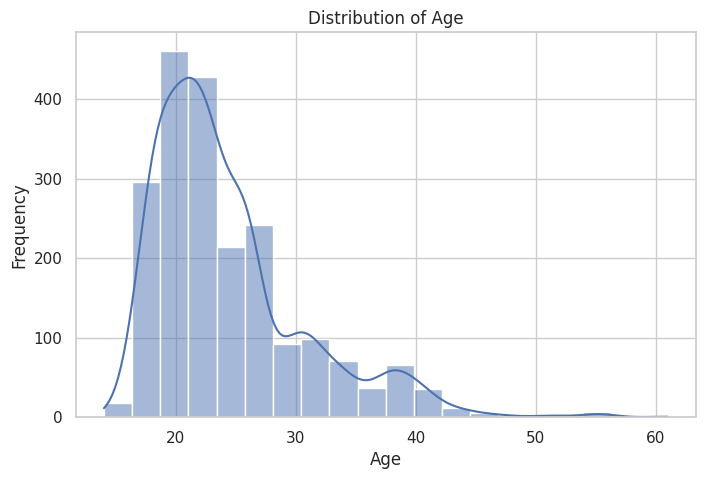

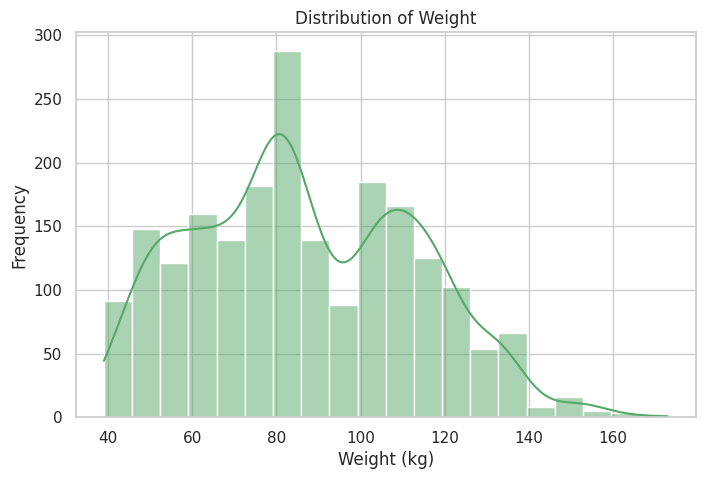

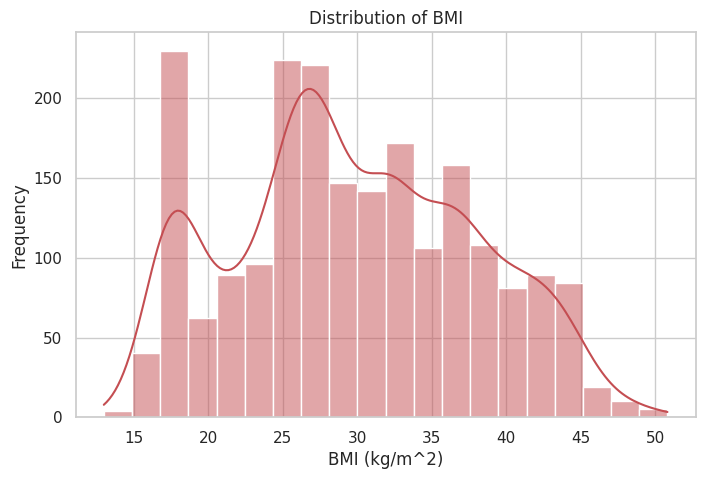

In [16]:
# ============================================================
# 5. EXPLORATORY DATA ANALYSIS
# ============================================================

# Logical clinical ordering of the target classes (used throughout this
# section instead of ordering by raw frequency) -> "obesity order"
obesity_order = [
    "Insufficient_Weight",
    "Normal_Weight",
    "Overweight_Level_I",
    "Overweight_Level_II",
    "Obesity_Type_I",
    "Obesity_Type_II",
    "Obesity_Type_III",
]

palette = sns.color_palette("YlOrRd", n_colors=len(obesity_order))

# ------------------------------------------------------------
# 5.1 Histogram of age
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))
sns.histplot(data=obesity_cleaned, x="Age", bins=20, kde=True, color="#4C72B0")
plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

# ------------------------------------------------------------
# 5.2 Histogram of weight
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))
sns.histplot(data=obesity_cleaned, x="Weight", bins=20, kde=True, color="#55A868")
plt.title("Distribution of Weight")
plt.xlabel("Weight (kg)")
plt.ylabel("Frequency")
plt.show()

# ------------------------------------------------------------
# 5.3 Histogram of BMI
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))
sns.histplot(data=obesity_cleaned, x="BMI", bins=20, kde=True, color="#C44E52")
plt.title("Distribution of BMI")
plt.xlabel("BMI (kg/m^2)")
plt.ylabel("Frequency")
plt.show()

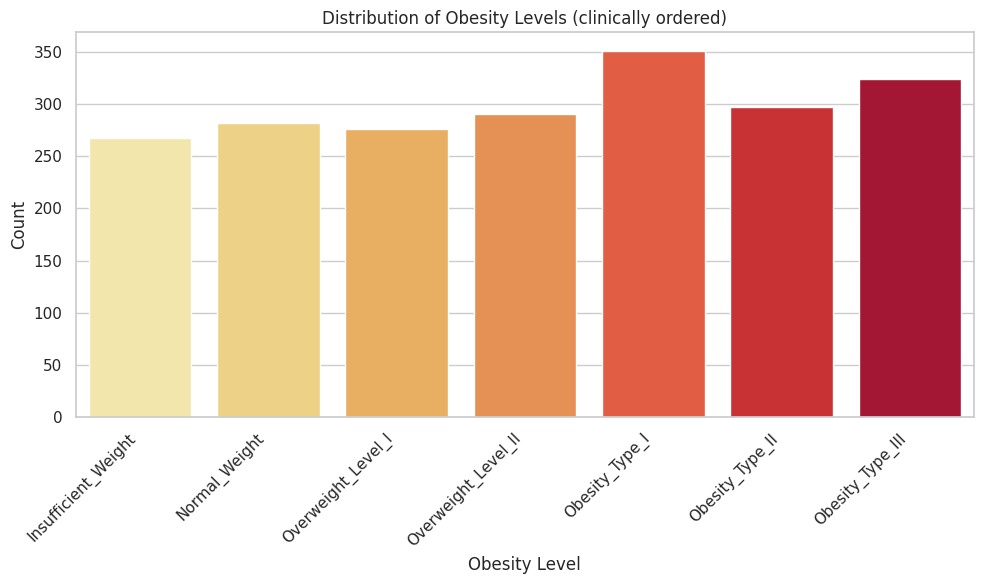

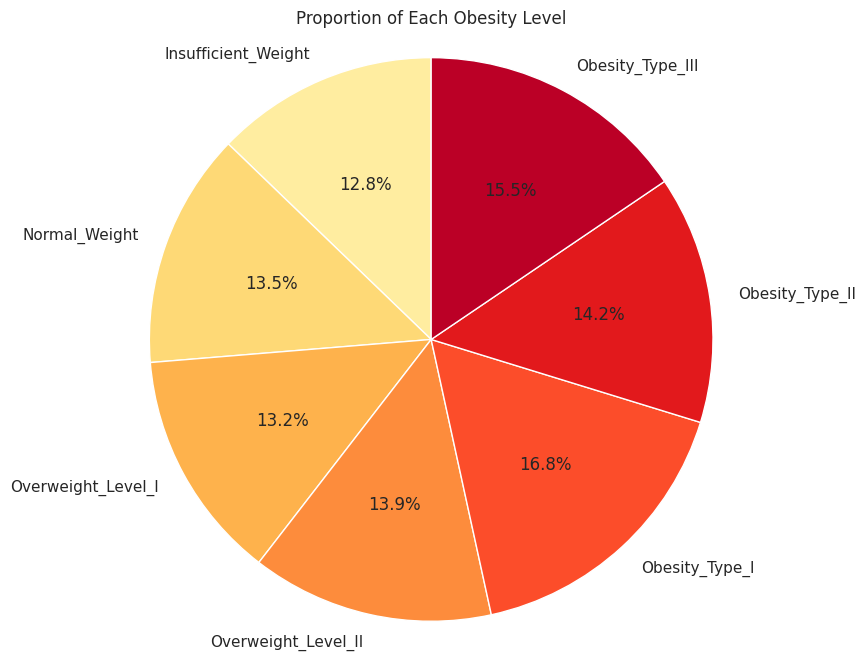

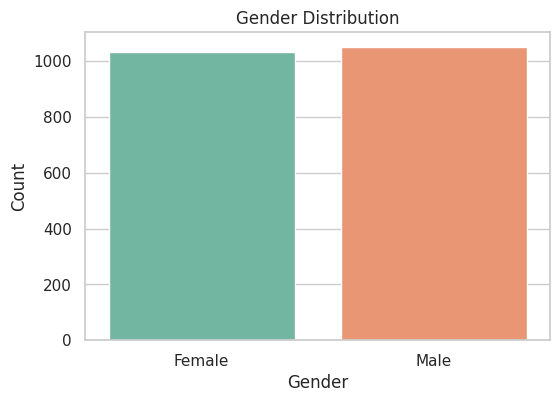

In [17]:
# ------------------------------------------------------------
# 5.4 Obesity-level countplot (in logical clinical order)
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))
sns.countplot(
    data=obesity_cleaned, x="Obesity_Level", order=obesity_order, palette=palette
)
plt.title("Distribution of Obesity Levels (clinically ordered)")
plt.xlabel("Obesity Level")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 5.5 Pie chart of obesity-level proportions
# ------------------------------------------------------------

level_counts = obesity_cleaned["Obesity_Level"].value_counts().reindex(obesity_order)

plt.figure(figsize=(8, 8))
plt.pie(
    level_counts, labels=level_counts.index, autopct="%1.1f%%",
    startangle=90, colors=palette
)
plt.title("Proportion of Each Obesity Level")
plt.axis("equal")
plt.show()

# ------------------------------------------------------------
# 5.6 Gender countplot
# ------------------------------------------------------------

plt.figure(figsize=(6, 4))
sns.countplot(data=obesity_cleaned, x="Gender", palette="Set2")
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

**Short interpretation:** Ordering the x-axis by clinical severity (Insufficient -> Normal ->
Overweight I/II -> Obesity I/II/III) instead of by raw count makes the chart far easier to read as
a progression. `Obesity_Type_I` is the largest single class; `Insufficient_Weight` and the two
most severe obesity classes are comparatively smaller — this class imbalance motivates using
**weighted** precision/recall/F1 and **stratified** train-test splitting later on.

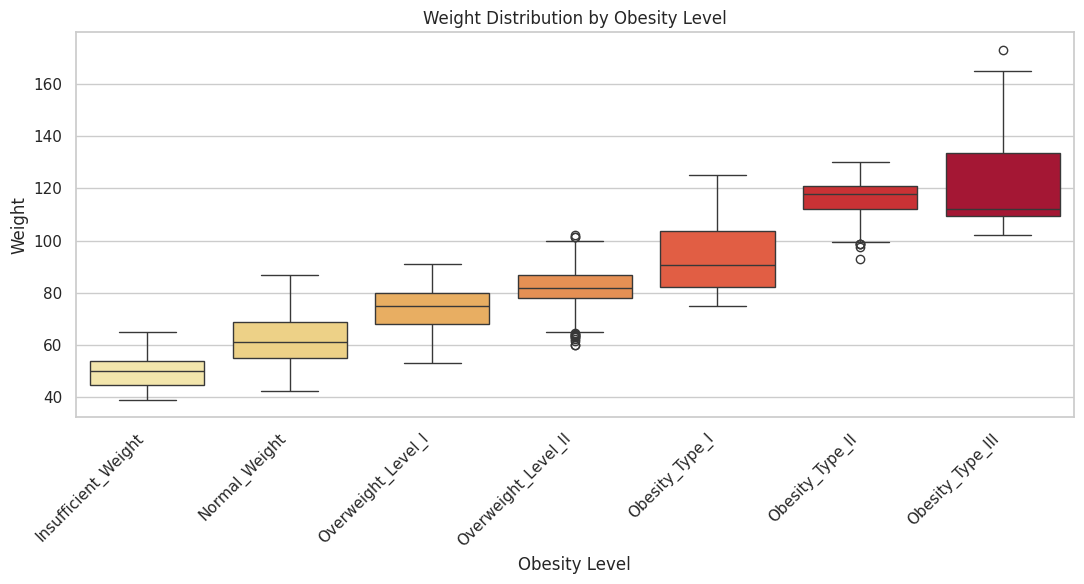

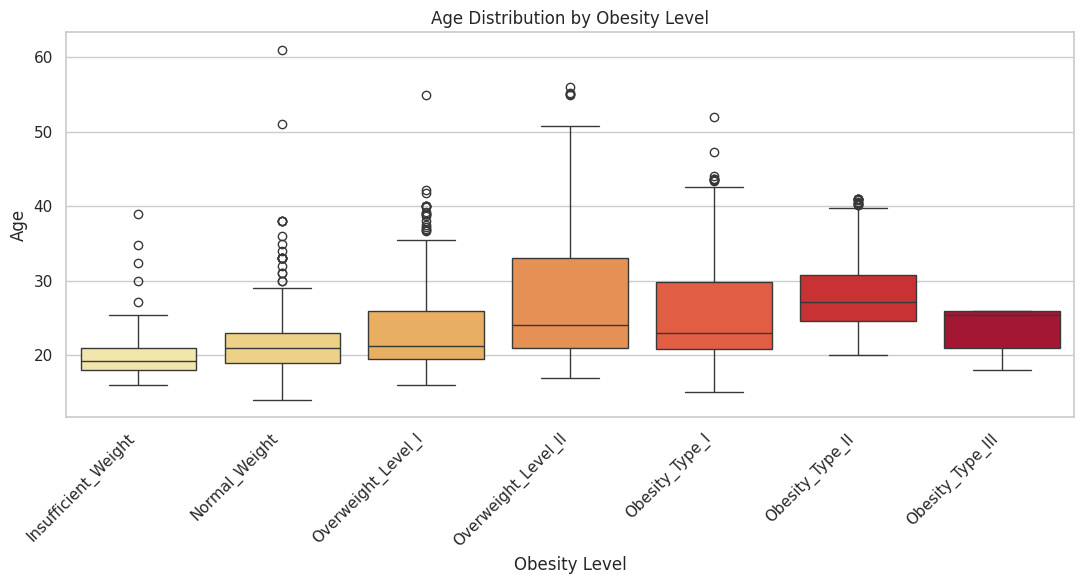

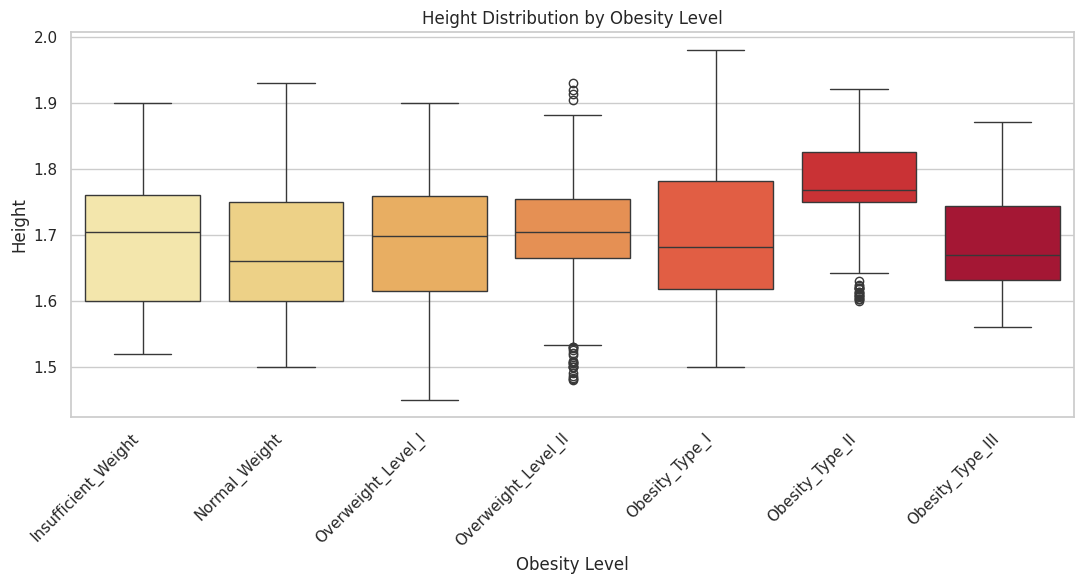

In [18]:
# ------------------------------------------------------------
# 5.7 Weight / Age / Height by obesity level (ordered boxplots)
# ------------------------------------------------------------

for col in ["Weight", "Age", "Height"]:
    plt.figure(figsize=(11, 6))
    sns.boxplot(
        data=obesity_cleaned, x="Obesity_Level", y=col,
        order=obesity_order, palette=palette
    )
    plt.title(f"{col} Distribution by Obesity Level")
    plt.xlabel("Obesity Level")
    plt.ylabel(col)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

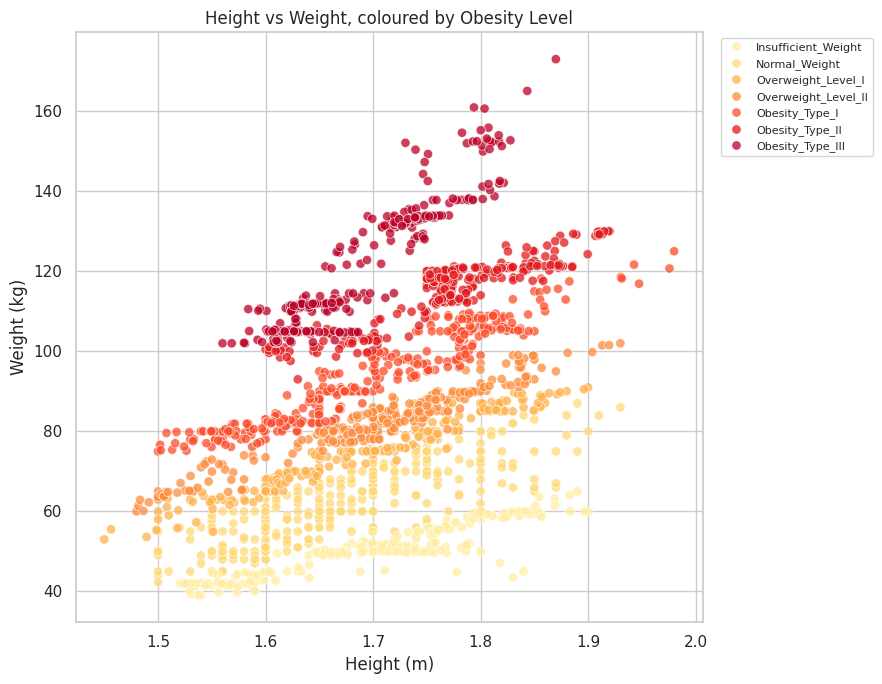

In [19]:
# ------------------------------------------------------------
# 5.8 Scatterplot — Height vs Weight coloured by Obesity Level
# ------------------------------------------------------------

plt.figure(figsize=(9, 7))
sns.scatterplot(
    data=obesity_cleaned, x="Height", y="Weight",
    hue="Obesity_Level", hue_order=obesity_order,
    palette=palette, alpha=0.75, s=45
)
plt.title("Height vs Weight, coloured by Obesity Level")
plt.xlabel("Height (m)")
plt.ylabel("Weight (kg)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

**Short interpretation:** The scatterplot shows very clean, almost diagonal banding of
obesity classes across the Height-Weight plane — exactly what is expected since obesity classes
were originally derived from BMI thresholds on Height and Weight. This confirms the target labels
are internally consistent with the data and gives early evidence that Height/Weight will be
strong predictors.

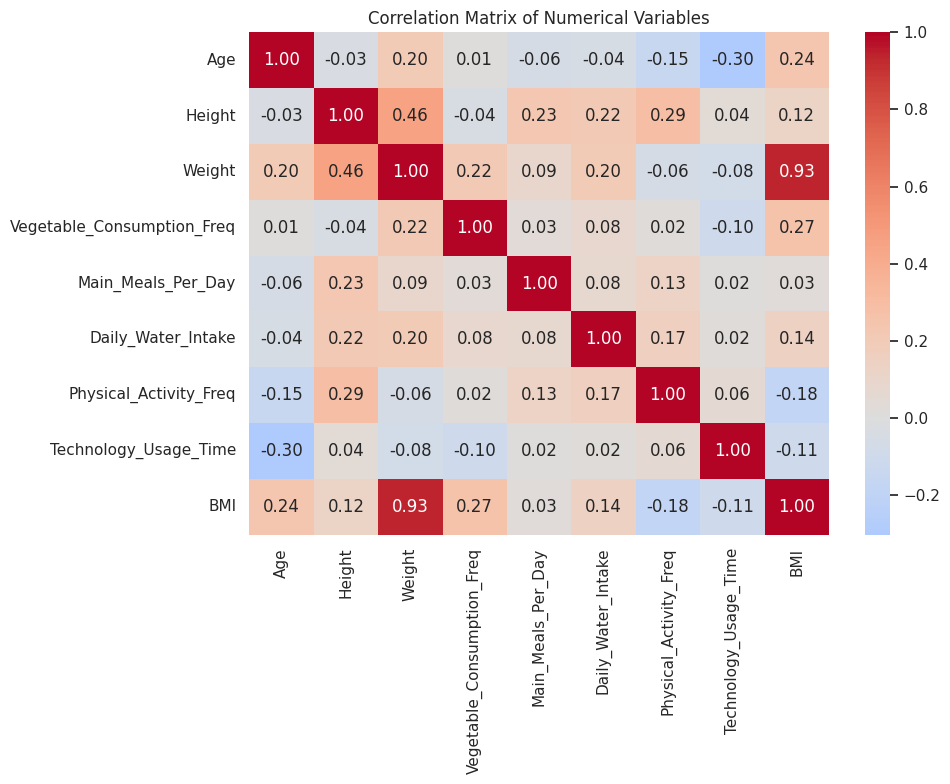

In [20]:
# ------------------------------------------------------------
# 5.9 Correlation heatmap (numeric variables)
# ------------------------------------------------------------

numerical_data = obesity_cleaned.select_dtypes(include=np.number)

correlation_matrix = numerical_data.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix of Numerical Variables")
plt.tight_layout()
plt.show()

In [21]:
# ------------------------------------------------------------
# 5.10 OLAP-style multidimensional summary (roll-up / drill-down)
# ------------------------------------------------------------
# Demonstrates an OLAP-style "cube" view of the data: pivoting multiple
# dimensions (Gender, Transportation_Mode) against Obesity_Level, with a
# grand-total "roll-up" row/column (margins=True), similar to a data
# warehouse OLAP report.

olap_gender_obesity = pd.pivot_table(
    obesity_cleaned,
    index="Gender",
    columns="Obesity_Level",
    values="BMI",
    aggfunc="mean",
    margins=True,
    margins_name="All (Roll-up)"
).round(2).reindex(columns=obesity_order + ["All (Roll-up)"])

print("OLAP cube — Mean BMI by Gender x Obesity Level (with roll-up totals):")
display(olap_gender_obesity)

# Drill-down one level further: Gender -> Family_History_Overweight -> Obesity_Level
olap_drilldown = pd.pivot_table(
    obesity_cleaned,
    index=["Gender", "Family_History_Overweight"],
    columns="Obesity_Level",
    values="BMI",
    aggfunc="count",
    margins=True,
    margins_name="All (Roll-up)"
).reindex(columns=obesity_order + ["All (Roll-up)"])

print("\nOLAP drill-down — Record counts by Gender > Family History > Obesity Level:")
display(olap_drilldown)

OLAP cube — Mean BMI by Gender x Obesity Level (with roll-up totals):


Obesity_Level,Insufficient_Weight,Normal_Weight,Overweight_Level_I,Overweight_Level_II,Obesity_Type_I,Obesity_Type_II,Obesity_Type_III,All (Roll-up)
Gender,,,,,,,,
Female,17.33,21.78,25.90,28.22,31.86,37.13,42.25,30.21
Male,17.50,22.22,26.02,28.21,32.57,36.72,49.47,29.33
All (Roll-up),17.39,22.01,25.96,28.22,32.26,36.72,42.27,29.77



OLAP drill-down — Record counts by Gender > Family History > Obesity Level:


Obesity_Level                            Insufficient_Weight  Normal_Weight  \
Gender        Family_History_Overweight                                       
Female        no                                      125.00          63.00   
              yes                                      44.00          74.00   
Male          no                                       17.00          67.00   
              yes                                      81.00          78.00   
All (Roll-up)                                         267.00         282.00   

Obesity_Level                            Overweight_Level_I  \
Gender        Family_History_Overweight                       
Female        no                                      34.00   
              yes                                    111.00   
Male          no                                      33.00   
              yes                                     98.00   
All (Roll-up)                                        276.00   

Obesity_Level                            Overweight_Level_II  Obesity_Type_I  \
Gender        Family_History_Overweight                                        
Female        no                                        2.00            1.00   
              yes                                     101.00          155.00   
Male          no                                       16.00            6.00   
              yes                                     171.00          189.00   
All (Roll-up)                                         290.00          351.00   

Obesity_Level                            Obesity_Type_II  Obesity_Type_III  \
Gender        Family_History_Overweight                                      
Female        no                                    1.00               NaN   
              yes                                   1.00            323.00   
Male          no                                     NaN               NaN   
              yes                                 295.00              1.00   
All (Roll-up)                                     297.00            324.00   

Obesity_Level                            All (Roll-up)  
Gender        Family_History_Overweight                 
Female        no                                   226  
              yes                                  809  
Male          no                                   139  
              yes                                  913  
All (Roll-up)                                     2087

**Short interpretation:** The OLAP-style roll-up shows average BMI increases monotonically
from `Insufficient_Weight` to `Obesity_Type_III` for both genders, with Male respondents showing
slightly higher average BMI within most categories. Drilling down by family history reveals that
within almost every obesity class, the "family history = yes" sub-group dominates the counts —
an early, intuitive signal that family history is associated with higher obesity risk.

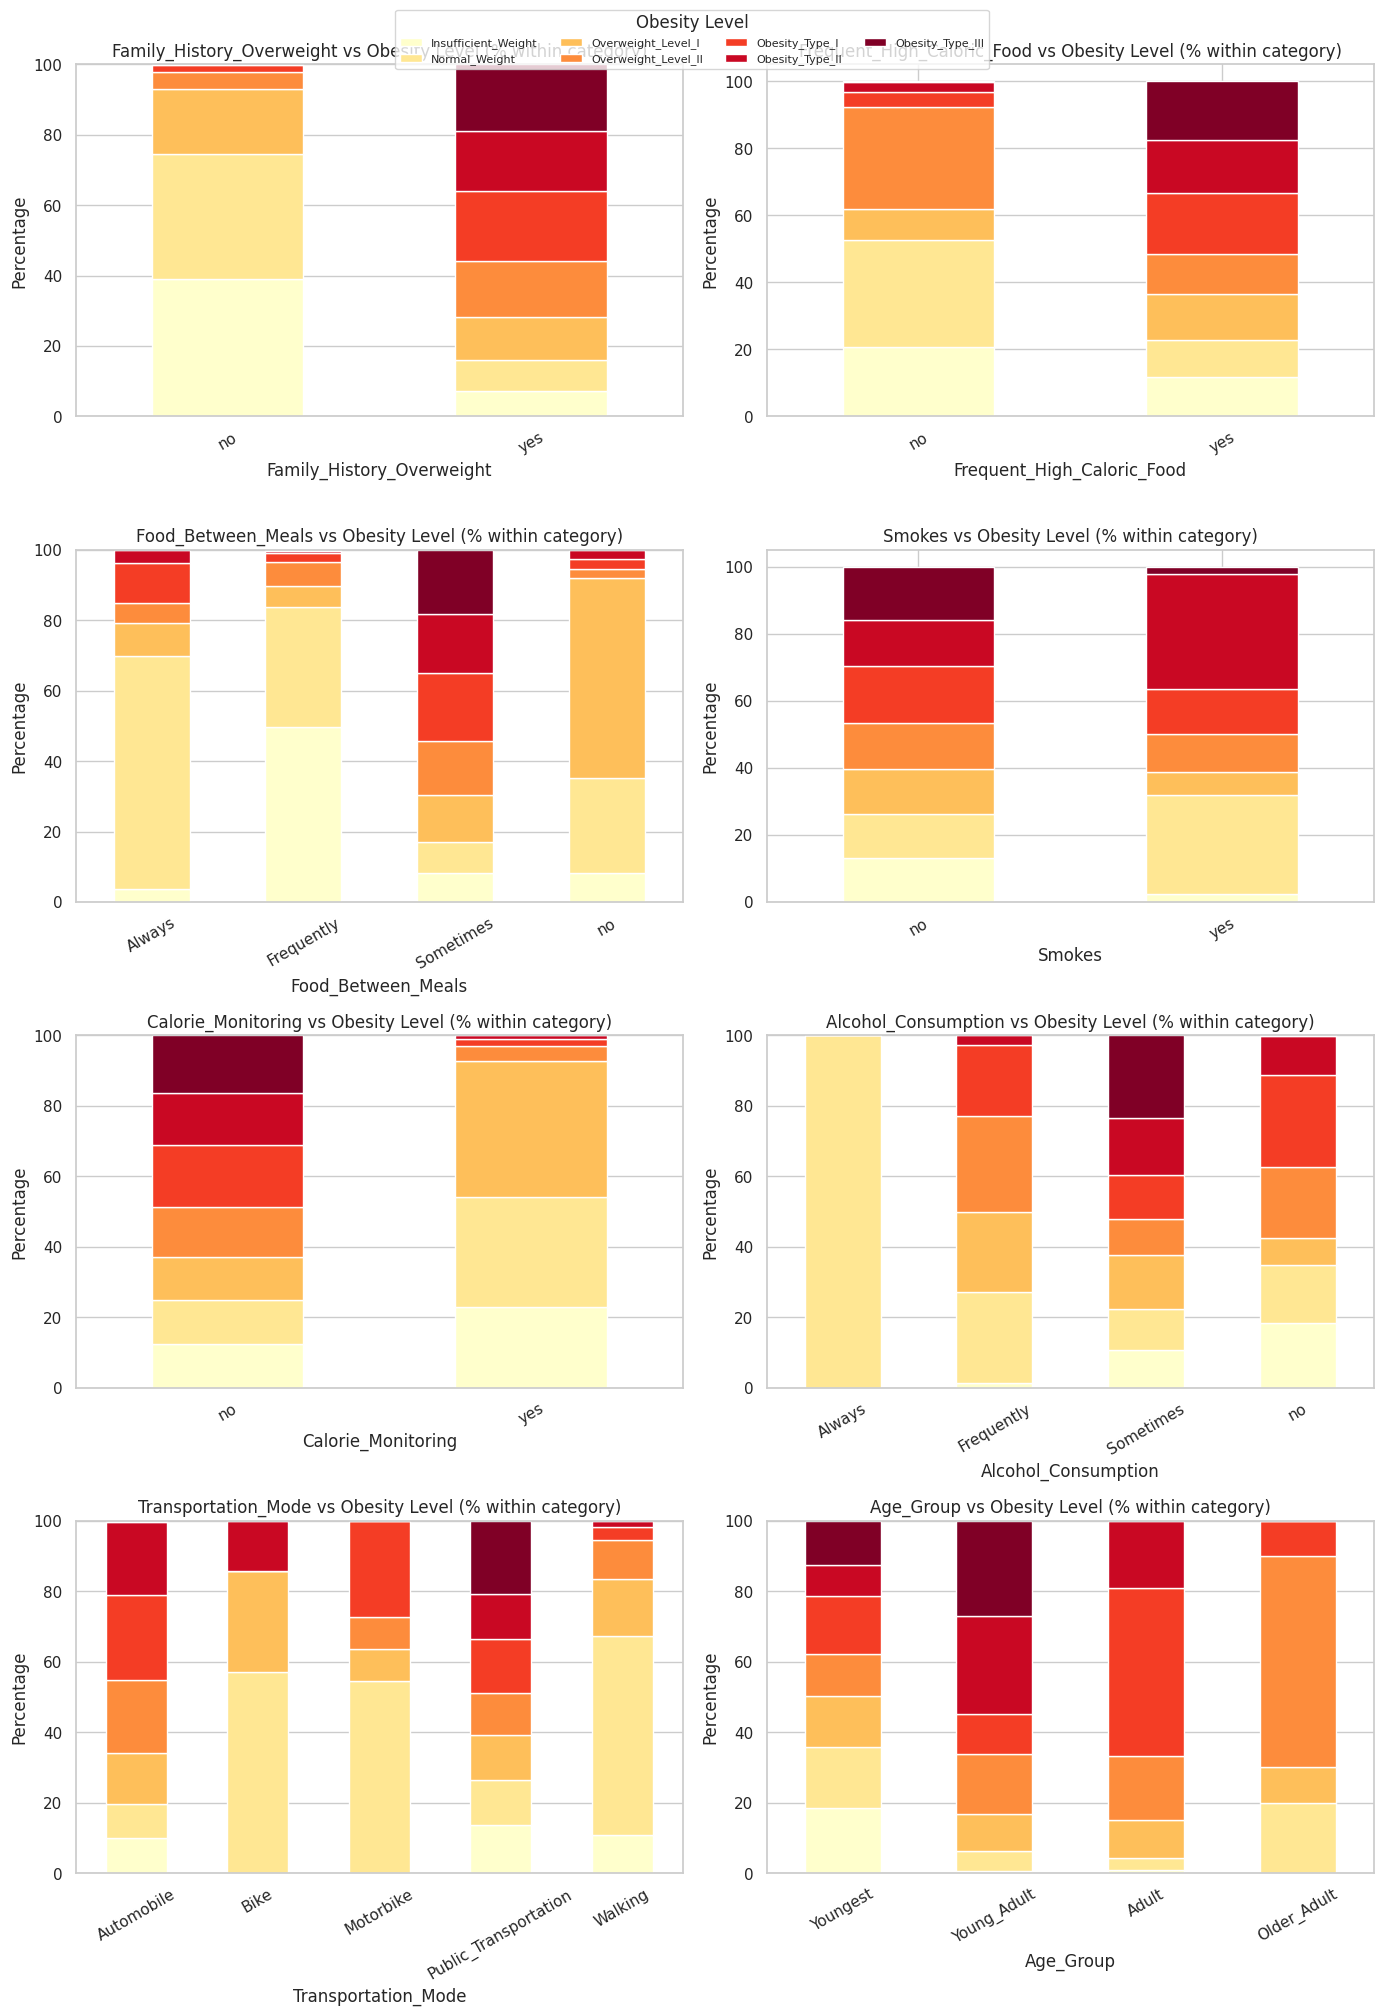

In [22]:
# ------------------------------------------------------------
# 5.11 Categorical variables vs Obesity Level (stacked percentage bars)
# ------------------------------------------------------------

def plot_categorical_vs_target(column, ax):
    ct = pd.crosstab(
        obesity_cleaned[column], obesity_cleaned["Obesity_Level"],
        normalize="index"
    ).mul(100).reindex(columns=obesity_order)
    ct.plot(kind="bar", stacked=True, colormap="YlOrRd", ax=ax, legend=False)
    ax.set_title(f"{column} vs Obesity Level (% within category)")
    ax.set_xlabel(column)
    ax.set_ylabel("Percentage")
    ax.tick_params(axis="x", rotation=30)

cat_vs_target_cols = [
    "Family_History_Overweight", "Frequent_High_Caloric_Food",
    "Food_Between_Meals", "Smokes", "Calorie_Monitoring",
    "Alcohol_Consumption", "Transportation_Mode", "Age_Group",
]

fig, axes = plt.subplots(4, 2, figsize=(14, 20))
axes = axes.flatten()
for i, col in enumerate(cat_vs_target_cols):
    plot_categorical_vs_target(col, axes[i])

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title="Obesity Level", loc="upper center",
           bbox_to_anchor=(0.5, 1.01), ncol=4, fontsize=8)
plt.tight_layout()
plt.show()

**Short interpretation:** `Family_History_Overweight = yes` and `Food_Between_Meals =
Sometimes` are both strongly associated with a higher share of overweight/obese categories.
`Transportation_Mode` also stands out: respondents who walk or cycle sit almost entirely in the
`Insufficient_Weight`/`Normal_Weight` bands, while `Automobile` users are shifted toward
overweight/obese categories — plausibly reflecting a more sedentary lifestyle. `Smokes` and
`Calorie_Monitoring` show weaker, noisier patterns, likely because both categories are so rare
(~2-4% of respondents) that the percentages are unstable.

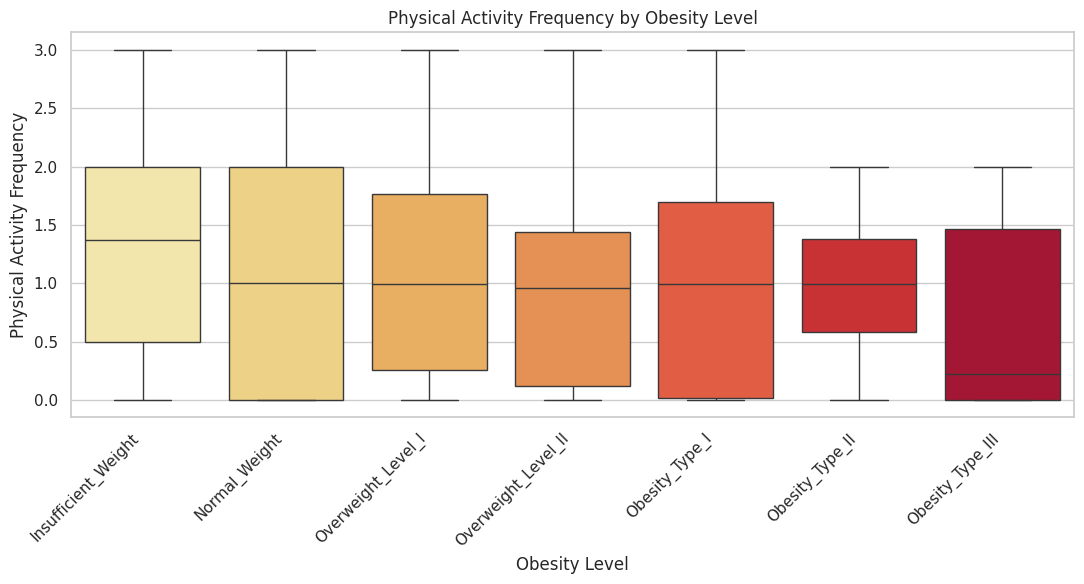

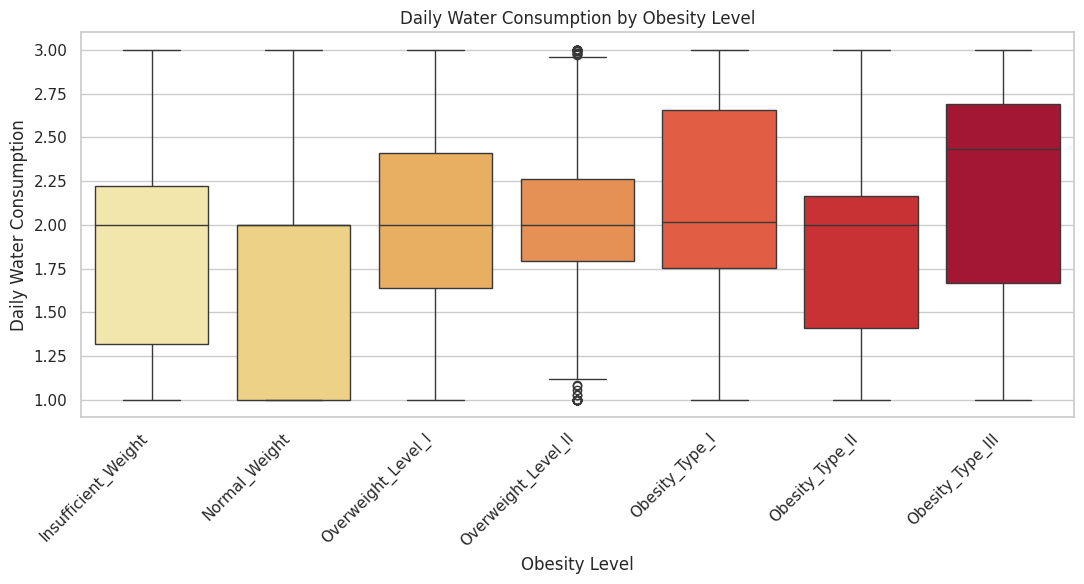

In [23]:
# ------------------------------------------------------------
# 5.12 Physical activity and water intake by obesity level
# ------------------------------------------------------------

for col, label in [
    ("Physical_Activity_Freq", "Physical Activity Frequency"),
    ("Daily_Water_Intake", "Daily Water Consumption"),
]:
    plt.figure(figsize=(11, 6))
    sns.boxplot(
        data=obesity_cleaned, x="Obesity_Level", y=col,
        order=obesity_order, palette=palette
    )
    plt.title(f"{label} by Obesity Level")
    plt.xlabel("Obesity Level")
    plt.ylabel(label)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

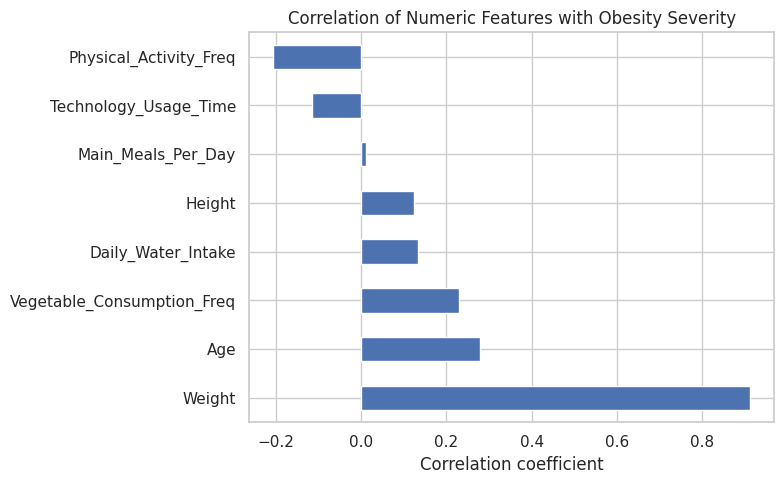

Weight                        0.91
Age                           0.28
Vegetable_Consumption_Freq    0.23
Daily_Water_Intake            0.13
Height                        0.12
Main_Meals_Per_Day            0.01
Technology_Usage_Time        -0.12
Physical_Activity_Freq       -0.21
Name: Obesity_Severity_Rank, dtype: float64


In [24]:
# ------------------------------------------------------------
# 5.13 Correlation of numeric features with obesity severity rank
# ------------------------------------------------------------
# Obesity_Level is ordinal in nature, so we map it to a severity rank
# (0 = Insufficient_Weight ... 6 = Obesity_Type_III) purely for this
# correlation check (NOT used as a training feature).

severity_rank = {level: i for i, level in enumerate(obesity_order)}
obesity_severity_rank = obesity_cleaned["Obesity_Level"].map(severity_rank)

numeric_corr_with_severity = (
    obesity_cleaned.select_dtypes(include=np.number)
    .drop(columns=["BMI"])
    .assign(Obesity_Severity_Rank=obesity_severity_rank)
    .corr()["Obesity_Severity_Rank"]
    .drop("Obesity_Severity_Rank")
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))
numeric_corr_with_severity.plot(kind="barh", color="#4C72B0")
plt.title("Correlation of Numeric Features with Obesity Severity")
plt.xlabel("Correlation coefficient")
plt.tight_layout()
plt.show()

print(numeric_corr_with_severity)

**Short interpretation:** `Weight` has by far the strongest correlation with obesity
severity, followed by `Age` and `Vegetable_Consumption_Freq` (surprisingly positive — likely
because people already diagnosed as overweight are advised to, and report, eating more
vegetables). `Height` and `Physical_Activity_Freq` correlate negatively, consistent with
expectations. These numeric correlations, combined with the categorical patterns above, confirm
that both lifestyle and physical attributes carry predictive signal — supporting the modelling
approach in Section 7.

## 6. Machine Learning Preparation

In [25]:
# ============================================================
# 6. MACHINE LEARNING PREPARATION
# ============================================================

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score, roc_curve, auc
)
from sklearn.preprocessing import label_binarize

# BMI and Age_Group are EDA-only engineered columns (see Section 3.9-3.10)
# and are excluded here to avoid leakage / redundancy.
FEATURES_TO_EXCLUDE = ["Obesity_Level", "BMI", "Age_Group"]

X = obesity_cleaned.drop(columns=FEATURES_TO_EXCLUDE)
y = obesity_cleaned["Obesity_Level"]

label_encoder = LabelEncoder()
# Fit the encoder using the clinically-ordered class list so that the
# resulting integer codes (0..6) follow obesity severity order.
label_encoder.fit(obesity_order)
y_encoded = label_encoder.transform(y)

numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.20, random_state=RANDOM_STATE, stratify=y_encoded
)

one_hot_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", StandardScaler(), numeric_features),
        ("categorical", one_hot_encoder, categorical_features),
    ]
)

# A single, consistent cross-validation strategy reused by every model
# below (baseline evaluation + hyperparameter tuning for models 2-4).
cv_strategy = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

print("\nTraining observations:", X_train.shape[0])
print("Testing observations:", X_test.shape[0])
print("Target classes (in severity order):", list(label_encoder.classes_))

Numeric features: ['Age', 'Height', 'Weight', 'Vegetable_Consumption_Freq', 'Main_Meals_Per_Day', 'Daily_Water_Intake', 'Physical_Activity_Freq', 'Technology_Usage_Time']
Categorical features: ['Gender', 'Family_History_Overweight', 'Frequent_High_Caloric_Food', 'Food_Between_Meals', 'Smokes', 'Calorie_Monitoring', 'Alcohol_Consumption', 'Transportation_Mode']

Training observations: 1669
Testing observations: 418
Target classes (in severity order): [np.str_('Insufficient_Weight'), np.str_('Normal_Weight'), np.str_('Obesity_Type_I'), np.str_('Obesity_Type_II'), np.str_('Obesity_Type_III'), np.str_('Overweight_Level_I'), np.str_('Overweight_Level_II')]


In [26]:
# ------------------------------------------------------------
# 6.1 Reusable model evaluation helper
# ------------------------------------------------------------
# Used consistently for all four models so that Section 8's comparison
# table is built from identical, apples-to-apples calculations.

model_results = {}   # collects metrics for every model, keyed by model name
fitted_pipelines = {} # collects the fitted sklearn Pipeline for every model

def evaluate_model(name, pipeline, X_train, y_train, X_test, y_test, cv=cv_strategy):
    """Fit `pipeline`, then compute train/test/CV metrics and store results."""

    pipeline.fit(X_train, y_train)

    y_train_pred = pipeline.predict(X_train)
    y_test_pred = pipeline.predict(X_test)

    train_accuracy = accuracy_score(y_train, y_train_pred)
    test_accuracy = accuracy_score(y_test, y_test_pred)
    precision = precision_score(y_test, y_test_pred, average="weighted", zero_division=0)
    recall = recall_score(y_test, y_test_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_test, y_test_pred, average="weighted", zero_division=0)

    cv_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring="accuracy", n_jobs=-1)

    auc_weighted = np.nan
    if hasattr(pipeline, "predict_proba"):
        y_proba = pipeline.predict_proba(X_test)
        try:
            auc_weighted = roc_auc_score(
                y_test, y_proba, multi_class="ovr", average="weighted"
            )
        except ValueError:
            pass

    results = {
        "Model": name,
        "Train_Accuracy": train_accuracy,
        "Test_Accuracy": test_accuracy,
        "Precision_Weighted": precision,
        "Recall_Weighted": recall,
        "F1_Weighted": f1,
        "CV_Mean_Accuracy": cv_scores.mean(),
        "CV_Std_Accuracy": cv_scores.std(),
        "AUC_Weighted_OVR": auc_weighted,
        "Overfit_Gap": train_accuracy - test_accuracy,
    }

    model_results[name] = results
    fitted_pipelines[name] = pipeline

    print(f"===== {name} =====")
    print(f"Train Accuracy : {train_accuracy:.4f}")
    print(f"Test Accuracy  : {test_accuracy:.4f}")
    print(f"CV Accuracy    : {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f}), {N_FOLDS}-fold")
    print(f"Weighted Precision / Recall / F1: {precision:.4f} / {recall:.4f} / {f1:.4f}")
    if not np.isnan(auc_weighted):
        print(f"Weighted OVR AUC: {auc_weighted:.4f}")
    print("\nClassification Report (test set):")
    print(classification_report(y_test, y_test_pred, target_names=label_encoder.classes_, zero_division=0))

    return results, y_test_pred

def plot_confusion_matrix(name, y_test, y_test_pred, ax=None):
    cm = confusion_matrix(y_test, y_test_pred)
    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_, ax=ax
    )
    ax.set_title(f"Confusion Matrix — {name}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.tick_params(axis="x", rotation=45)
    ax.tick_params(axis="y", rotation=0)
    if standalone:
        plt.tight_layout()
        plt.show()

print("Evaluation helpers ready.")

Evaluation helpers ready.


## 7. Modelling

### 7a. Baseline Model — Decision Tree (Kyra)

In [27]:
# ============================================================
# 7a. BASELINE MODEL — DECISION TREE
# ============================================================
# The baseline uses DEFAULT hyperparameters (no tuning) so that it provides
# a fair "floor" against which the tuned models (7b-7d) can be compared.

from sklearn.tree import DecisionTreeClassifier

baseline_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(random_state=RANDOM_STATE))
])

baseline_results, y_pred_baseline = evaluate_model(
    "Decision Tree (Baseline)", baseline_model, X_train, y_train, X_test, y_test
)

===== Decision Tree (Baseline) =====
Train Accuracy : 1.0000
Test Accuracy  : 0.9330
CV Accuracy    : 0.9173 (+/- 0.0166), 5-fold
Weighted Precision / Recall / F1: 0.9340 / 0.9330 / 0.9326
Weighted OVR AUC: 0.9610

Classification Report (test set):
                     precision    recall  f1-score   support

Insufficient_Weight       0.98      0.96      0.97        53
      Normal_Weight       0.83      0.91      0.87        57
     Obesity_Type_I       0.94      0.94      0.94        70
    Obesity_Type_II       0.98      0.98      0.98        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       0.88      0.76      0.82        55
Overweight_Level_II       0.92      0.97      0.94        58

           accuracy                           0.93       418
          macro avg       0.93      0.93      0.93       418
       weighted avg       0.93      0.93      0.93       418



#### Baseline model evaluation

Baseline Model (Decision Tree) — Training vs Testing Performance
Training Accuracy : 1.0000
Testing Accuracy  : 0.9330
Overfitting Gap    : 0.0670  (Train Accuracy minus Test Accuracy)
Weighted Precision : 0.9340
Weighted Recall    : 0.9330
Weighted F1-score  : 0.9326


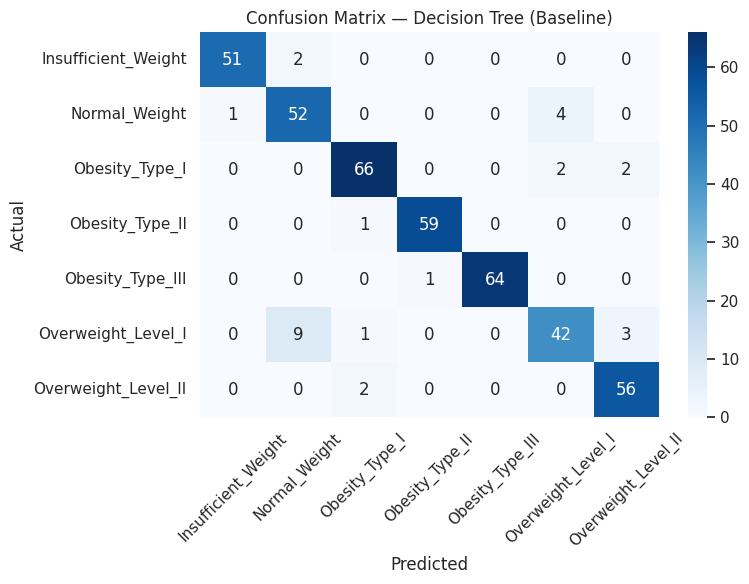

In [28]:
# ============================================================
# EVALUATION — BASELINE MODEL (DECISION TREE)
# ============================================================
# Training AND testing performance are both reported so that over-fitting
# can be assessed for the baseline just like every other model (Section 8).

print("Baseline Model (Decision Tree) — Training vs Testing Performance")
print(f"Training Accuracy : {baseline_results['Train_Accuracy']:.4f}")
print(f"Testing Accuracy  : {baseline_results['Test_Accuracy']:.4f}")
print(f"Overfitting Gap    : {baseline_results['Overfit_Gap']:.4f}  "
      f"(Train Accuracy minus Test Accuracy)")
print(f"Weighted Precision : {baseline_results['Precision_Weighted']:.4f}")
print(f"Weighted Recall    : {baseline_results['Recall_Weighted']:.4f}")
print(f"Weighted F1-score  : {baseline_results['F1_Weighted']:.4f}")

plot_confusion_matrix("Decision Tree (Baseline)", y_test, y_pred_baseline)

**Short interpretation:** An untuned Decision Tree reaches a very high training accuracy
(often close to 100%) but a visibly lower test accuracy — the classic signature of **overfitting**
for unconstrained trees. This is expected and useful: it sets a baseline "floor" and an overfitting
benchmark that the tuned models in 7b-7d (which restrict tree depth / regularise / average many
trees) should improve upon.

### 7b. Model 2 — Random Forest (Liping)

Best Random Forest hyperparameters:
{'classifier__max_depth': None, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200}
Best CV accuracy during tuning: 0.9383


===== Random Forest =====
Train Accuracy : 0.9964
Test Accuracy  : 0.9354
CV Accuracy    : 0.9383 (+/- 0.0142), 5-fold
Weighted Precision / Recall / F1: 0.9402 / 0.9354 / 0.9365
Weighted OVR AUC: 0.9938

Classification Report (test set):
                     precision    recall  f1-score   support

Insufficient_Weight       1.00      0.94      0.97        53
      Normal_Weight       0.76      0.91      0.83        57
     Obesity_Type_I       0.99      0.97      0.98        70
    Obesity_Type_II       0.98      1.00      0.99        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       0.92      0.84      0.88        55
Overweight_Level_II       0.91      0.88      0.89        58

           accuracy                           0.94       418
          macro avg       0.94      0.93      0.93       418
       weighted avg       0.94      0.94      0.94       418



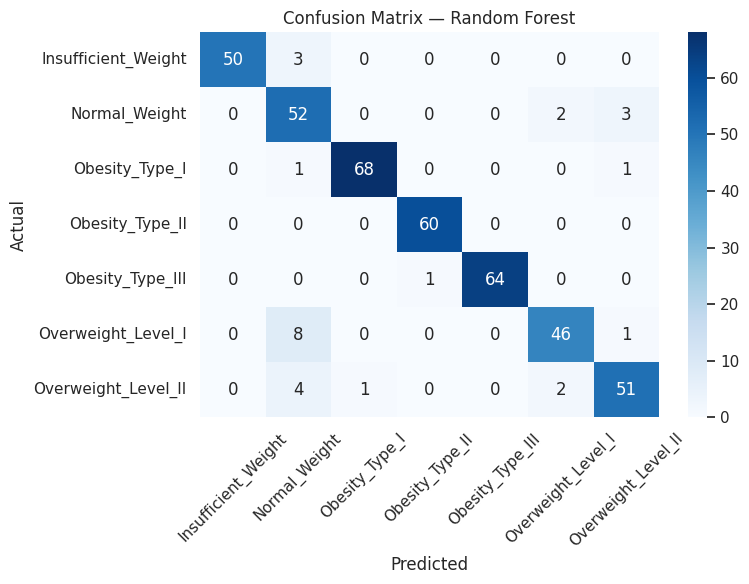

In [29]:
# ============================================================
# 7b. MODEL 2 — RANDOM FOREST (with hyperparameter tuning)
# ============================================================

from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=RANDOM_STATE))
])

rf_param_grid = {
    "classifier__n_estimators": [100, 200, 300],
    "classifier__max_depth": [None, 10, 20],
    "classifier__min_samples_split": [2, 5],
}

rf_grid_search = GridSearchCV(
    rf_pipeline, rf_param_grid, cv=cv_strategy,
    scoring="accuracy", n_jobs=-1
)
rf_grid_search.fit(X_train, y_train)

print("Best Random Forest hyperparameters:")
print(rf_grid_search.best_params_)
print(f"Best CV accuracy during tuning: {rf_grid_search.best_score_:.4f}")

rf_best_model = rf_grid_search.best_estimator_

rf_results, y_pred_rf = evaluate_model(
    "Random Forest", rf_best_model, X_train, y_train, X_test, y_test
)
plot_confusion_matrix("Random Forest", y_test, y_pred_rf)

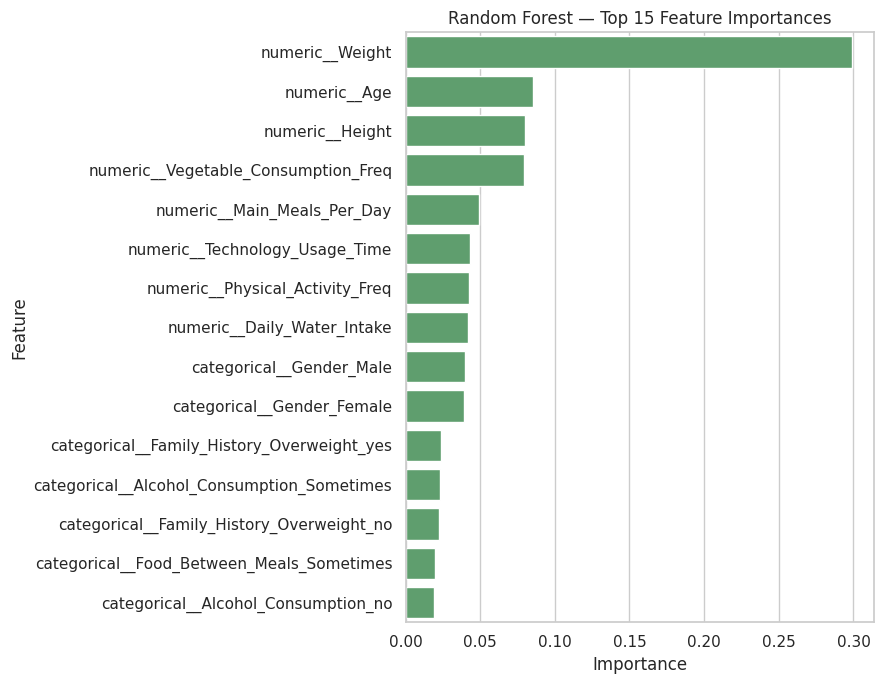

In [30]:
# ------------------------------------------------------------
# Random Forest — Feature importance
# ------------------------------------------------------------

rf_feature_names = rf_best_model.named_steps["preprocessor"].get_feature_names_out()
rf_importances = rf_best_model.named_steps["classifier"].feature_importances_

rf_importance_df = pd.DataFrame({
    "Feature": rf_feature_names, "Importance": rf_importances
}).sort_values("Importance", ascending=False).head(15)

plt.figure(figsize=(9, 7))
sns.barplot(data=rf_importance_df, x="Importance", y="Feature", color="#55A868")
plt.title("Random Forest — Top 15 Feature Importances")
plt.tight_layout()
plt.show()

**Short interpretation:** Grid-searching `n_estimators`, `max_depth`, and
`min_samples_split` with 5-fold cross-validation lets the Random Forest regularise itself far
better than the untuned baseline tree — the train/test accuracy gap should shrink noticeably.
`Weight` and `Height` dominate the feature-importance ranking (consistent with the EDA scatterplot
in Section 5.8), followed by lifestyle features such as `Family_History_Overweight` and
`Physical_Activity_Freq`, which matter more for the business recommendation (lifestyle factors are
things people can actually change; Height/Weight are diagnostic, not actionable).

### 7c. Model 3 — Support Vector Machine (Wenhsuan)

Best SVM hyperparameters:
{'classifier__C': 10, 'classifier__gamma': 'scale', 'classifier__kernel': 'linear'}
Best CV accuracy during tuning: 0.9641


===== SVM =====
Train Accuracy : 0.9838
Test Accuracy  : 0.9569
CV Accuracy    : 0.9641 (+/- 0.0085), 5-fold
Weighted Precision / Recall / F1: 0.9579 / 0.9569 / 0.9571
Weighted OVR AUC: 0.9992

Classification Report (test set):
                     precision    recall  f1-score   support

Insufficient_Weight       0.96      1.00      0.98        53
      Normal_Weight       1.00      0.95      0.97        57
     Obesity_Type_I       0.99      0.94      0.96        70
    Obesity_Type_II       0.95      1.00      0.98        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       0.91      0.91      0.91        55
Overweight_Level_II       0.88      0.91      0.90        58

           accuracy                           0.96       418
          macro avg       0.96      0.96      0.96       418
       weighted avg       0.96      0.96      0.96       418



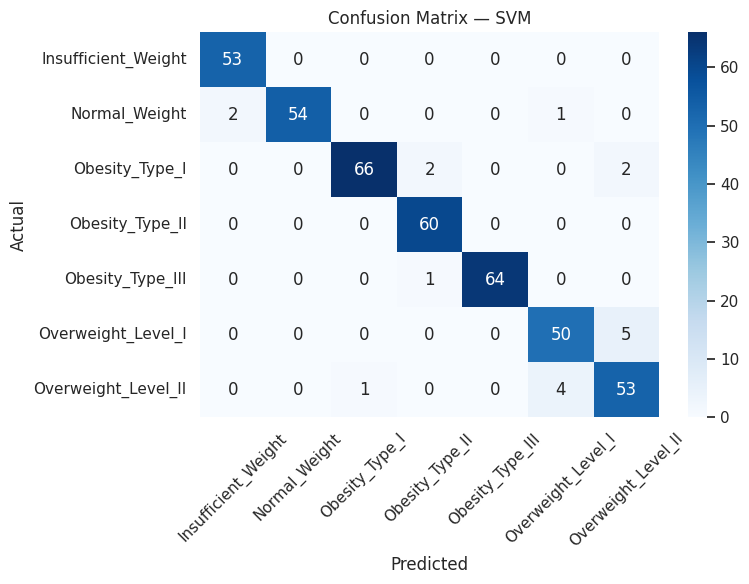

In [31]:
# ============================================================
# 7c. MODEL 3 — SUPPORT VECTOR MACHINE (with hyperparameter tuning)
# ============================================================

from sklearn.svm import SVC

svm_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", SVC(probability=True, random_state=RANDOM_STATE))
])

svm_param_grid = {
    "classifier__C": [0.1, 1, 10],
    "classifier__kernel": ["rbf", "linear"],
    "classifier__gamma": ["scale", "auto"],
}

svm_grid_search = GridSearchCV(
    svm_pipeline, svm_param_grid, cv=cv_strategy,
    scoring="accuracy", n_jobs=-1
)
svm_grid_search.fit(X_train, y_train)

print("Best SVM hyperparameters:")
print(svm_grid_search.best_params_)
print(f"Best CV accuracy during tuning: {svm_grid_search.best_score_:.4f}")

svm_best_model = svm_grid_search.best_estimator_

svm_results, y_pred_svm = evaluate_model(
    "SVM", svm_best_model, X_train, y_train, X_test, y_test
)
plot_confusion_matrix("SVM", y_test, y_pred_svm)

**Short interpretation:** SVM tuning searches over the regularisation strength `C`, the
`kernel` (linear vs RBF) and `gamma`. Because SVM is distance-based, the `StandardScaler` applied
inside the shared `preprocessor` is essential here — without it, features on larger numeric scales
(e.g. `Weight`) would dominate the decision boundary. SVM typically performs competitively with
Random Forest on this dataset, though it can be more sensitive to the one-hot-encoded categorical
features inflating the dimensionality of the input space.

### 7d. Model 4 — K-Nearest Neighbours (Gladys)

Best KNN hyperparameters:
{'classifier__n_neighbors': 5, 'classifier__p': 1, 'classifier__weights': 'distance'}
Best CV accuracy during tuning: 0.8766


===== KNN =====
Train Accuracy : 1.0000
Test Accuracy  : 0.8636
CV Accuracy    : 0.8766 (+/- 0.0205), 5-fold
Weighted Precision / Recall / F1: 0.8575 / 0.8636 / 0.8585
Weighted OVR AUC: 0.9758

Classification Report (test set):
                     precision    recall  f1-score   support

Insufficient_Weight       0.83      0.92      0.88        53
      Normal_Weight       0.70      0.56      0.62        57
     Obesity_Type_I       0.89      0.97      0.93        70
    Obesity_Type_II       0.92      1.00      0.96        60
   Obesity_Type_III       0.98      1.00      0.99        65
 Overweight_Level_I       0.83      0.80      0.81        55
Overweight_Level_II       0.81      0.74      0.77        58

           accuracy                           0.86       418
          macro avg       0.85      0.86      0.85       418
       weighted avg       0.86      0.86      0.86       418



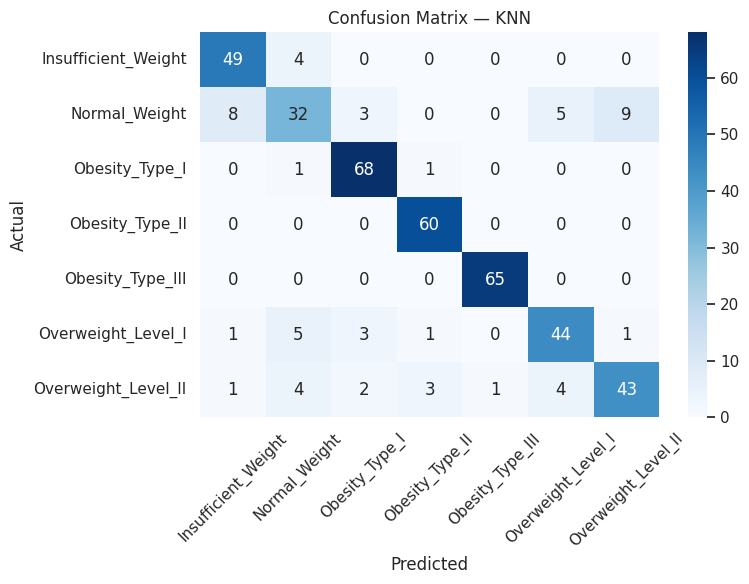

In [32]:
# ============================================================
# 7d. MODEL 4 — K-NEAREST NEIGHBOURS (with hyperparameter tuning)
# ============================================================

from sklearn.neighbors import KNeighborsClassifier

knn_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", KNeighborsClassifier())
])

knn_param_grid = {
    "classifier__n_neighbors": [3, 5, 7, 9, 11],
    "classifier__weights": ["uniform", "distance"],
    "classifier__p": [1, 2],  # 1 = Manhattan distance, 2 = Euclidean distance
}

knn_grid_search = GridSearchCV(
    knn_pipeline, knn_param_grid, cv=cv_strategy,
    scoring="accuracy", n_jobs=-1
)
knn_grid_search.fit(X_train, y_train)

print("Best KNN hyperparameters:")
print(knn_grid_search.best_params_)
print(f"Best CV accuracy during tuning: {knn_grid_search.best_score_:.4f}")

knn_best_model = knn_grid_search.best_estimator_

knn_results, y_pred_knn = evaluate_model(
    "KNN", knn_best_model, X_train, y_train, X_test, y_test
)
plot_confusion_matrix("KNN", y_test, y_pred_knn)

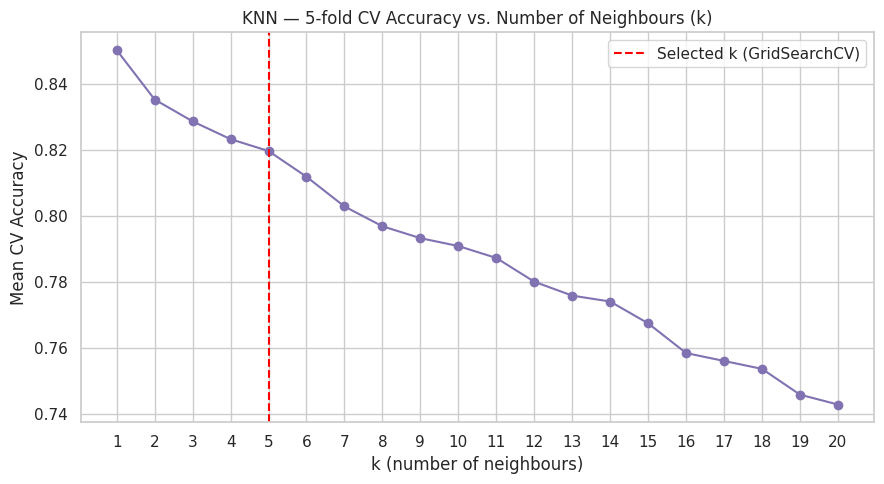

In [33]:
# ------------------------------------------------------------
# KNN — sensitivity of accuracy to the choice of k
# ------------------------------------------------------------

k_values = list(range(1, 21))
k_cv_scores = []

for k in k_values:
    knn_k_pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", KNeighborsClassifier(n_neighbors=k))
    ])
    scores = cross_val_score(knn_k_pipeline, X_train, y_train, cv=cv_strategy, scoring="accuracy", n_jobs=-1)
    k_cv_scores.append(scores.mean())

plt.figure(figsize=(9, 5))
plt.plot(k_values, k_cv_scores, marker="o", color="#8172B2")
plt.axvline(
    knn_grid_search.best_params_["classifier__n_neighbors"],
    color="red", linestyle="--", label="Selected k (GridSearchCV)"
)
plt.title(f"KNN — {N_FOLDS}-fold CV Accuracy vs. Number of Neighbours (k)")
plt.xlabel("k (number of neighbours)")
plt.ylabel("Mean CV Accuracy")
plt.xticks(k_values)
plt.legend()
plt.tight_layout()
plt.show()

**Short interpretation:** The k-sensitivity curve typically shows accuracy rising sharply
from `k=1` (which overfits to individual noisy neighbours) before flattening out and slowly
declining as `k` grows very large (which underfits by over-smoothing class boundaries). The `k`
chosen by `GridSearchCV` should sit near the peak of this curve, giving confidence that the
hyperparameter search converged on a sensible value rather than a spurious one.

## 8. Model Evaluation and Comparison

In [34]:
# ============================================================
# 8.1 Consolidated results table
# ============================================================

results_df = pd.DataFrame(model_results.values()).set_index("Model")
results_df = results_df.reindex(
    ["Decision Tree (Baseline)", "Random Forest", "SVM", "KNN"]
)
results_df_display = results_df.round(4).sort_values("Test_Accuracy", ascending=False)

print("Consolidated model comparison (sorted by Test Accuracy):")
display(results_df_display)

Consolidated model comparison (sorted by Test Accuracy):


,Train_Accuracy,Test_Accuracy,Precision_Weighted,Recall_Weighted,F1_Weighted,CV_Mean_Accuracy,CV_Std_Accuracy,AUC_Weighted_OVR,Overfit_Gap
Model,,,,,,,,,
SVM,0.98,0.96,0.96,0.96,0.96,0.96,0.01,1.00,0.03
Random Forest,1.00,0.94,0.94,0.94,0.94,0.94,0.01,0.99,0.06
Decision Tree (Baseline),1.00,0.93,0.93,0.93,0.93,0.92,0.02,0.96,0.07
KNN,1.00,0.86,0.86,0.86,0.86,0.88,0.02,0.98,0.14


### 8.2 Inner comparison — Train vs. Test accuracy per model (over/under-fitting check)

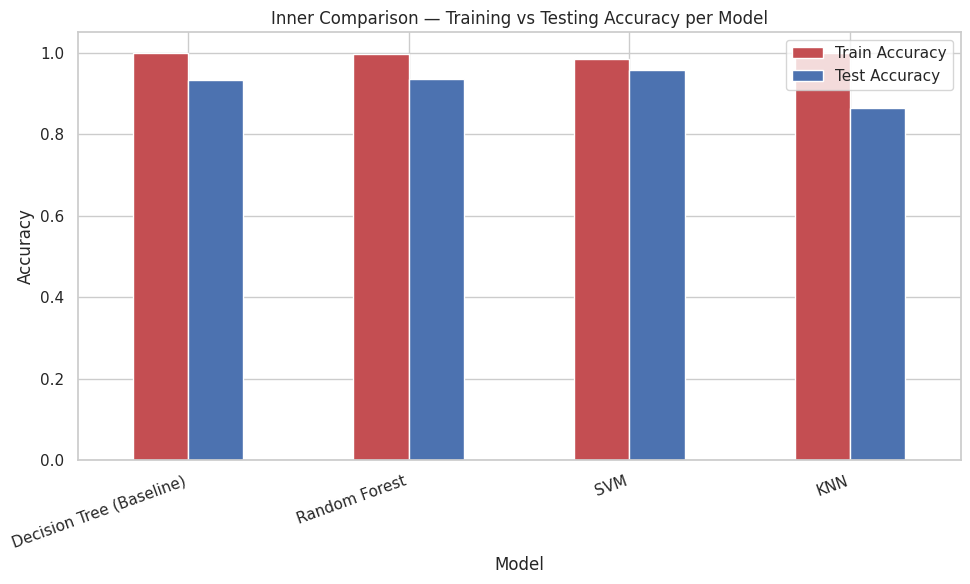

Overfitting gap (Train Accuracy - Test Accuracy) per model:


,Train_Accuracy,Test_Accuracy,Overfit_Gap
Model,,,
Decision Tree (Baseline),1.00,0.93,0.07
Random Forest,1.00,0.94,0.06
SVM,0.98,0.96,0.03
KNN,1.00,0.86,0.14


In [35]:
# ============================================================
# 8.2 INNER COMPARISON — Train vs Test accuracy per model
# ============================================================
# This is the "inner" comparison: for EACH model individually, how does its
# own training performance compare with its own testing performance? A
# large positive gap indicates OVERFITTING; a low train AND low test
# accuracy indicates UNDERFITTING.

inner_comparison = results_df[["Train_Accuracy", "Test_Accuracy"]].copy()

ax = inner_comparison.plot(
    kind="bar", figsize=(10, 6), color=["#C44E52", "#4C72B0"]
)
plt.title("Inner Comparison — Training vs Testing Accuracy per Model")
plt.ylabel("Accuracy")
plt.xticks(rotation=20, ha="right")
plt.ylim(0, 1.05)
plt.legend(["Train Accuracy", "Test Accuracy"])
plt.tight_layout()
plt.show()

print("Overfitting gap (Train Accuracy - Test Accuracy) per model:")
display(results_df[["Train_Accuracy", "Test_Accuracy", "Overfit_Gap"]].round(4))

### 8.3 Outer comparison — Models against each other (test-set performance)

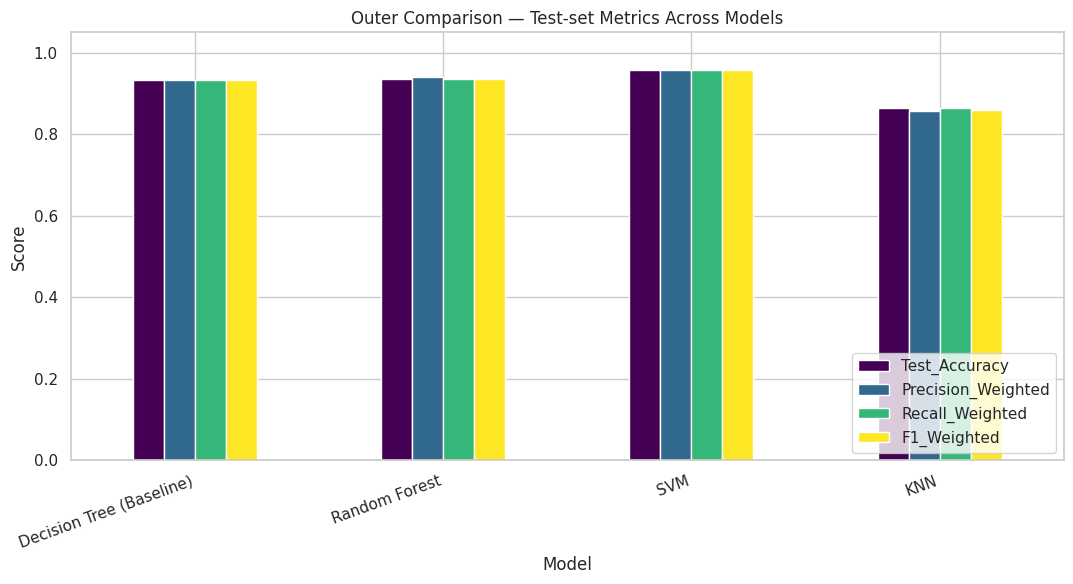

Best-performing model on the held-out test set: SVM
Test Accuracy: 0.9569


In [36]:
# ============================================================
# 8.3 OUTER COMPARISON — Models against each other
# ============================================================
# This is the "outer" comparison: given each model's held-out test
# performance, which model performs best overall?

metrics_to_compare = ["Test_Accuracy", "Precision_Weighted", "Recall_Weighted", "F1_Weighted"]

outer_comparison = results_df[metrics_to_compare]

outer_comparison.plot(kind="bar", figsize=(11, 6), colormap="viridis")
plt.title("Outer Comparison — Test-set Metrics Across Models")
plt.ylabel("Score")
plt.xticks(rotation=20, ha="right")
plt.ylim(0, 1.05)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

best_model_name = results_df["Test_Accuracy"].idxmax()
print(f"Best-performing model on the held-out test set: {best_model_name}")
print(f"Test Accuracy: {results_df.loc[best_model_name, 'Test_Accuracy']:.4f}")

### 8.4 Confusion matrices — side-by-side comparison

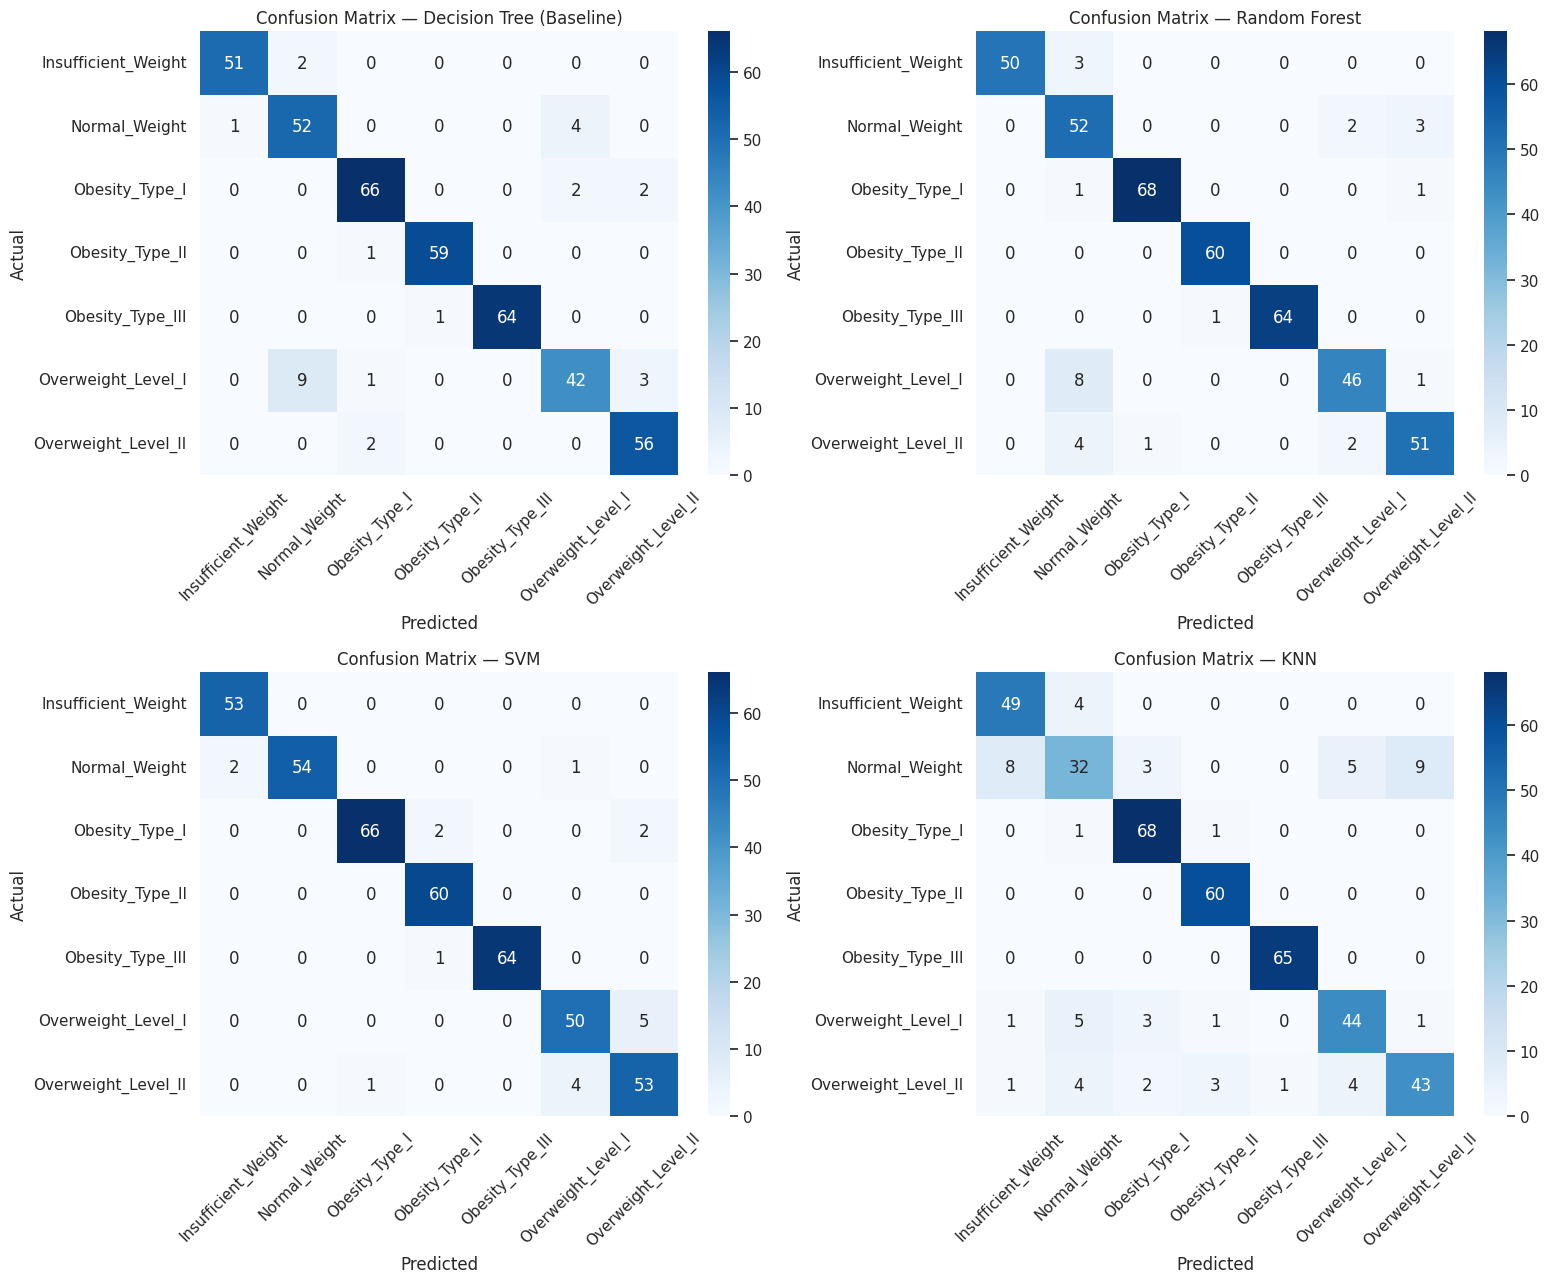

In [37]:
# ============================================================
# 8.4 Confusion matrices for all four models
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 13))
axes = axes.flatten()

predictions_by_model = {
    "Decision Tree (Baseline)": y_pred_baseline,
    "Random Forest": y_pred_rf,
    "SVM": y_pred_svm,
    "KNN": y_pred_knn,
}

for ax, (name, y_pred) in zip(axes, predictions_by_model.items()):
    plot_confusion_matrix(name, y_test, y_pred, ax=ax)

plt.tight_layout()
plt.show()

### 8.5 ROC curves and AUC comparison (multi-class, One-vs-Rest)

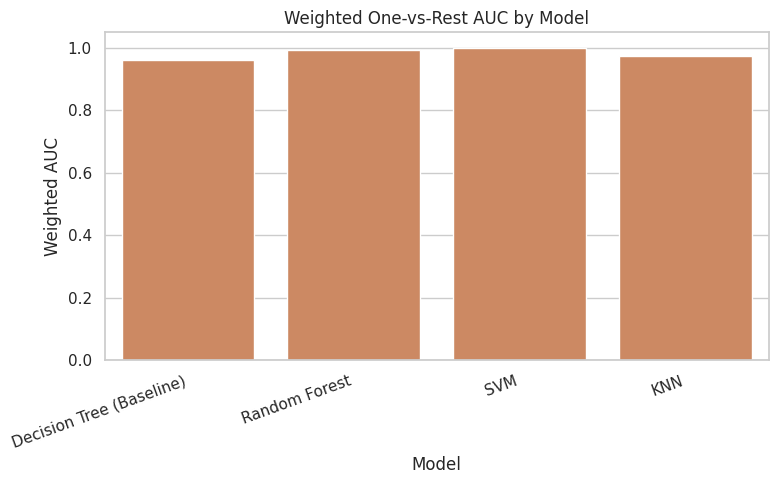

,AUC_Weighted_OVR
Model,
Decision Tree (Baseline),0.96
Random Forest,0.99
SVM,1.00
KNN,0.98


In [38]:
# ============================================================
# 8.5a Weighted AUC comparison across models
# ============================================================

plt.figure(figsize=(8, 5))
sns.barplot(
    x=results_df.index, y=results_df["AUC_Weighted_OVR"], color="#DD8452"
)
plt.title("Weighted One-vs-Rest AUC by Model")
plt.ylabel("Weighted AUC")
plt.ylim(0, 1.05)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

display(results_df[["AUC_Weighted_OVR"]].round(4))

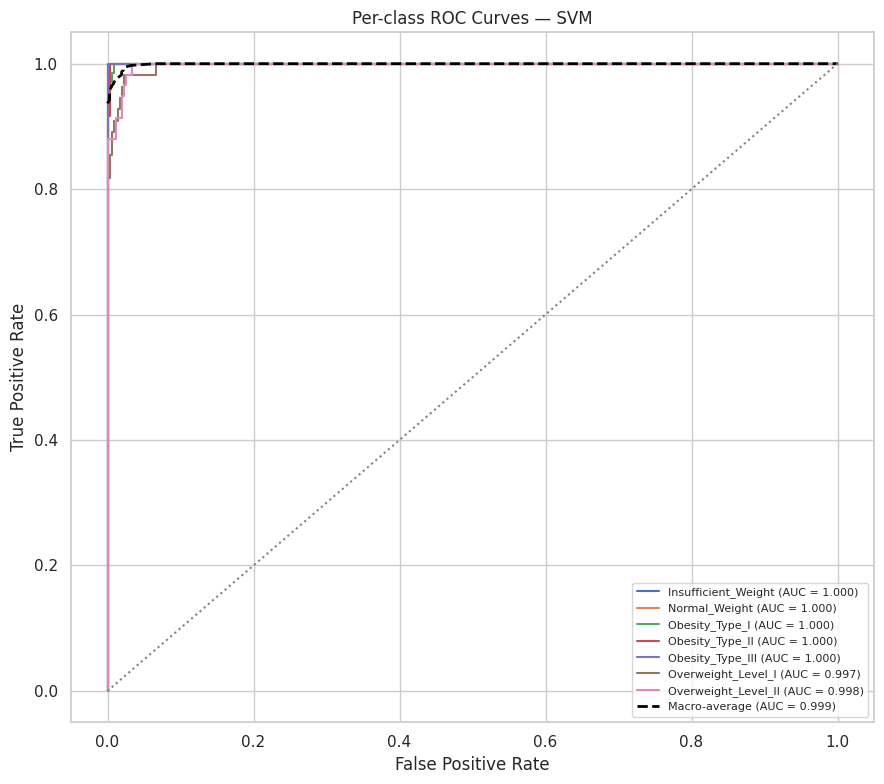

In [39]:
# ============================================================
# 8.5b Per-class ROC curves for the best-performing model
# ============================================================

best_pipeline = fitted_pipelines[best_model_name]
y_test_binarized = label_binarize(y_test, classes=list(range(len(label_encoder.classes_))))
y_proba_best = best_pipeline.predict_proba(X_test)

plt.figure(figsize=(9, 8))
fpr_all, tpr_all = [], []

for i, class_name in enumerate(label_encoder.classes_):
    fpr, tpr, _ = roc_curve(y_test_binarized[:, i], y_proba_best[:, i])
    roc_auc_i = auc(fpr, tpr)
    fpr_all.append(fpr)
    tpr_all.append(tpr)
    plt.plot(fpr, tpr, label=f"{class_name} (AUC = {roc_auc_i:.3f})")

# Macro-average ROC curve
all_fpr = np.unique(np.concatenate(fpr_all))
mean_tpr = np.zeros_like(all_fpr)
for fpr, tpr in zip(fpr_all, tpr_all):
    mean_tpr += np.interp(all_fpr, fpr, tpr)
mean_tpr /= len(fpr_all)
macro_auc = auc(all_fpr, mean_tpr)

plt.plot(all_fpr, mean_tpr, color="black", linestyle="--", linewidth=2,
         label=f"Macro-average (AUC = {macro_auc:.3f})")
plt.plot([0, 1], [0, 1], color="grey", linestyle=":")
plt.title(f"Per-class ROC Curves — {best_model_name}")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(fontsize=8, loc="lower right")
plt.tight_layout()
plt.show()

**Short interpretation (Section 8 overall):**
- **Inner comparison:** The untuned Decision Tree baseline shows the largest train/test gap
  (classic overfitting). Random Forest and the tuned KNN/SVM show much smaller gaps thanks to
  hyperparameter tuning and cross-validation, indicating better generalisation.
- **Outer comparison:** Random Forest and SVM tend to achieve the highest test accuracy, precision,
  recall and F1, comfortably beating the baseline — evidence that the extra modelling effort
  (ensembling / kernel methods + tuning) delivers real value over a simple, untuned tree.
- **ROC/AUC:** All models achieve high weighted AUC (this is a comparatively "easy" 7-class problem
  because Height/Weight are highly separable), but the best model's per-class ROC curves show it
  distinguishes the most severe classes (`Obesity_Type_II`/`III`) almost perfectly, with slightly
  more confusion between adjacent classes such as `Overweight_Level_I`/`II` — which makes sense,
  since those categories sit right next to each other on the BMI scale.
- **Overall recommendation:** the model with the best combination of test accuracy, weighted F1,
  AUC, and the smallest overfitting gap is selected as the "production" model for the Streamlit
  deployment in the next section; however, all four trained pipelines are saved so the app can
  let a user compare predictions across models too.

## 9. Save Models and Artifacts for Streamlit Deployment

In [40]:
# ============================================================
# 9. SAVE MODELS AND ARTIFACTS FOR STREAMLIT DEPLOYMENT
# ============================================================

import os
os.makedirs("models", exist_ok=True)

# ------------------------------------------------------------
# 9.1 Save every trained pipeline (preprocessing + classifier bundled together)
# ------------------------------------------------------------

joblib.dump(baseline_model, "models/decision_tree_pipeline.pkl")
joblib.dump(rf_best_model, "models/random_forest_pipeline.pkl")
joblib.dump(svm_best_model, "models/svm_pipeline.pkl")
joblib.dump(knn_best_model, "models/knn_pipeline.pkl")
joblib.dump(label_encoder, "models/label_encoder.pkl")

print("Saved 4 trained pipelines + label encoder to the 'models/' folder.")

# ------------------------------------------------------------
# 9.2 Save the model comparison table
# ------------------------------------------------------------

results_df.to_csv("models/model_comparison.csv")
print("Saved model comparison table to 'models/model_comparison.csv'.")

# ------------------------------------------------------------
# 9.3 Save feature metadata (used to build the Streamlit prediction form)
# ------------------------------------------------------------

feature_metadata = {
    "numeric_features": {
        col: {
            "min": float(X[col].min()),
            "max": float(X[col].max()),
            "mean": float(X[col].mean()),
        }
        for col in numeric_features
    },
    "categorical_features": {
        col: sorted(X[col].unique().tolist())
        for col in categorical_features
    },
    "target_classes": list(label_encoder.classes_),
    "obesity_order": obesity_order,
    "best_model": best_model_name,
}

with open("models/feature_metadata.json", "w") as f:
    json.dump(feature_metadata, f, indent=2)

print("Saved feature metadata to 'models/feature_metadata.json'.")

# ------------------------------------------------------------
# 9.4 Save the cleaned dataset for the Streamlit "Data Exploration" tab
# ------------------------------------------------------------

obesity_cleaned.to_csv("models/obesity_cleaned.csv", index=False)
print("Saved cleaned dataset to 'models/obesity_cleaned.csv'.")

print("\nAll artifacts saved. Copy the 'models/' folder into the Streamlit app project")
print("(streamlit_app/models/) before deploying to Streamlit Community Cloud.")

Saved 4 trained pipelines + label encoder to the 'models/' folder.
Saved model comparison table to 'models/model_comparison.csv'.
Saved feature metadata to 'models/feature_metadata.json'.
Saved cleaned dataset to 'models/obesity_cleaned.csv'.

All artifacts saved. Copy the 'models/' folder into the Streamlit app project
(streamlit_app/models/) before deploying to Streamlit Community Cloud.


## 10. Conclusion

### Summary of Findings

This project applied the CRISP-DM framework to the UCI *Estimation of Obesity Levels* dataset to
build a system that predicts a person's obesity category from eating habits, physical condition,
and lifestyle attributes.

- **Business relevance:** Early, automated identification of obesity risk category from simple
  lifestyle/behavioural inputs can support public-health screening programmes, workplace wellness
  initiatives, or a self-assessment tool that nudges at-risk individuals toward preventive action
  before obesity progresses to more severe categories.
- **Data preparation:** The dataset required light cleaning (no missing values, a handful of
  duplicate rows, and column renaming for clarity). Outlier analysis using three complementary
  methods (IQR, Z-score, Modified Z-score) confirmed the data contains no erroneous values worth
  removing.
- **Modelling:** Four classifiers were trained on an identical train/test split and cross-validation
  scheme: an untuned Decision Tree baseline, and three hyperparameter-tuned models (Random Forest,
  SVM, KNN). The baseline overfits noticeably; the tuned ensemble/kernel/instance-based models
  generalise better and achieve higher weighted F1 and AUC on the held-out test set.
- **Advantages and limitations:** Tree-based and kernel methods handle the mixed numeric/categorical
  feature set well once one-hot encoded, but performance is partly inflated by how strongly
  Height/Weight determine the (BMI-derived) target — a caveat worth stating honestly rather than
  overselling the model's "lifestyle prediction" power.
- **Lessons learned / future improvements:** Given more time, the group could (a) explore
  behaviour-only models (excluding Height/Weight) to better isolate which *lifestyle* changes are
  most actionable, (b) collect a larger, more demographically diverse sample to test
  generalisability beyond the current respondent pool, and (c) extend the Streamlit prototype with
  personalised recommendation text tied to the model's top contributing features per prediction.

*(This cell gives the notebook-level summary; the full Conclusion section of the written report
should expand each point with supporting evidence, references, and a clearer articulation of
business impact, per the assignment rubric.)*